# 裂纹图像识别系统 —— 无监督学习聚类方法专题报告

> 《机器学习与 Python 编程》研究性专题 · 无监督学习方向  
> 负责：蔡昊伭  
> 本报告聚焦 **K-Means、GMM、DBSCAN、层次聚类、谱聚类** 五种无监督聚类方法，并通过 **PCA 降维分析** 揭示裂缝/非裂缝在高维特征空间中的天然椭球簇结构。  
> 报告将核心流程、关键代码、参数含义和实验结果整合在同一个 Notebook 中，便于独立阅读和复现实验思路。

---

## 报告摘要

本项目任务为表面裂纹图像二分类：`1` 表示有裂纹，`0` 表示无裂纹。数据集共 **40,000 张** `.jpg` 图像，正负样本各 **20,000 张**，类别天然均衡。无监督学习不依赖标签，通过发现数据的内在结构进行分组，可用于自动发现裂缝与非裂缝的天然分组，或在无标注场景下进行初步筛查。

| 维度 | 结论 |
|------|------|
| 数据分布 | 正负样本完全均衡，Quick-Run 模式下取 2000 张样本进行快速验证 |
| 特征工程 | HOG + LBP + GLCM + 边缘密度，四类手工特征拼接为高维特征向量 |
| 中心法/概率法 | K-Means 和 GMM 在特征空间中表现一致，聚类轮廓系数为 **0.0395**，ARI 为 **0.1039** |
| 密度法 | DBSCAN 易产生大量噪声点，在明确的两类分割问题上非最优选择 |
| 层次法 | 层次聚类（Ward 链接）表现出最好的综合指标，轮廓系数 **0.0628**，ARI **0.1534**，NMI **0.1934** |
| 图论法 | 谱聚类（RBF 核）ARI≈0，几乎随机分配；PCA 降维后退化为单簇 |
| 三重证据 | ① 10 种子 ARI 全 0.9139 ② >=10 维 GMM 稳定 0.91+ ③ full 协方差 >> spherical |
| **PCA 降维后** | **GMM ARI 从 0.10 暴涨至 0.9139**，K-Means 仍停留在 0.10，说明簇结构真实存在，但被高维噪声掩盖，且簇呈椭球状非球形 |
| 工程选择 | 原始特征：Ward 层次聚类最优（ARI=0.15）；**PCA 降维后：GMM(full) 最优（ARI=0.91）**，为无标注筛查提供可行方案 |

---

## 一、数据集与统一实验设置

### 1.1 数据集结构

- **任务**：表面裂纹图像二分类（`1` = 有裂纹 / Positive，`0` = 无裂纹 / Negative）
- **规模**：共 **40,000 张** `.jpg` 图像，正负样本各 **20,000** 张
- **无监督评估指标**：
  - **内部指标**（无需真实标签）：轮廓系数（Silhouette Score）、Davies-Bouldin 指数、Calinski-Harabasz 指数
  - **外部指标**（需真实标签作为参考）：调整兰德指数（ARI）、归一化互信息（NMI）

### 1.2 统一实验流程

> 图像读取（灰度） → CLAHE 对比度增强 → 中值滤波去噪 → HOG/LBP/GLCM/边缘密度特征提取 → 聚类模型训练 → 内部+外部指标评估

### 1.3 五种聚类方法概览

| 方法 | 类别 | 核心思想 | 关键特点 |
|------|------|----------|----------|
| **K-Means** | 中心法 | 最小化簇内平方距离 | 高效快速，适合球形簇 |
| **GMM** | 概率法 | 高斯分布混合建模（EM 算法） | 软聚类，支持椭圆簇，输出归属概率 |
| **DBSCAN** | 密度法 | 连通密度区域 | 任意形状簇，自动识别噪声点 |
| **层次聚类** | 层次法 | 凝聚式构建层次树 | 可探索层次结构，无需预设簇数 |
| **谱聚类** | 图论法 | 图拉普拉斯特征分解 | 适合非凸形状和复杂结构 |
| **监督学习对比** | 监督 | LightGBM / XGBoost / SVM 等 | Test F1=0.9438，远优于无监督最优 |


In [ ]:
# 0. 环境配置与实验结果表
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

RUN_FULL_EXPERIMENT = False

# ---- 原始特征空间聚类结果 ----
# 数据来源：outputs/results/unsupervised_comparison_full.csv
unsupervised_results = pd.DataFrame([
    {"method": "K-Means",         "n_clusters": 2, "n_noise": 0,
     "silhouette": 0.0395, "davies_bouldin": 4.9089, "calinski_harabasz": 78.05,
     "ari": 0.1039, "nmi": 0.0808},
    {"method": "GMM",             "n_clusters": 2, "n_noise": 0,
     "silhouette": 0.0395, "davies_bouldin": 4.9089, "calinski_harabasz": 78.05,
     "ari": 0.1039, "nmi": 0.0808},
    {"method": "层次聚类(ward)",  "n_clusters": 2, "n_noise": 0,
     "silhouette": 0.0628, "davies_bouldin": 4.9018, "calinski_harabasz": 61.27,
     "ari": 0.1534, "nmi": 0.1934},
    {"method": "谱聚类(rbf)",     "n_clusters": 2, "n_noise": 0,
     "silhouette": -0.0407, "davies_bouldin": 1.0802, "calinski_harabasz": 1.65,
     "ari": 0.0, "nmi": 0.002},
    {"method": "DBSCAN",          "n_clusters": float("nan"), "n_noise": float("nan"),
     "silhouette": float("nan"), "davies_bouldin": float("nan"), "calinski_harabasz": float("nan"),
     "ari": float("nan"), "nmi": float("nan"),
     "note": "未找到有效的 2 簇参数组合"},
])

# ---- PCA 降维前后对比（核心发现） ----
# 数据来源：outputs/results/unsupervised_pca_comparison.csv
pca_comparison = pd.DataFrame([
    {"method": "K-Means",
     "silhouette_orig": 0.0395, "silhouette_pca": 0.1141,
     "CH_orig": 78.05, "CH_pca": 247.03,
     "ari_orig": 0.1039, "ari_pca": 0.1026},
    {"method": "GMM",
     "silhouette_orig": 0.0395, "silhouette_pca": 0.091,
     "CH_orig": 78.05, "CH_pca": 83.6,
     "ari_orig": 0.1039, "ari_pca": 0.9139},  # 暴涨 8.8 倍！
    {"method": "层次聚类(ward)",
     "silhouette_orig": 0.0628, "silhouette_pca": 0.0989,
     "CH_orig": 61.27, "CH_pca": 200.06,
     "ari_orig": 0.1534, "ari_pca": 0.1193},
    {"method": "谱聚类(rbf)",
     "silhouette_orig": -0.0407, "silhouette_pca": float("nan"),
     "CH_orig": 1.65, "CH_pca": float("nan"),
     "ari_orig": 0.0, "ari_pca": 0.0,
     "note": "PCA 降维后退化为单簇"},
])

print("=== 原始特征空间 ===")
display(unsupervised_results)
print("
=== PCA 降维前后对比（核心发现）===")
display(pca_comparison)


In [ ]:
# 1. 数据读取与图像预处理核心代码
import os
import cv2
import numpy as np
from pathlib import Path
from typing import Optional, Tuple
from dotenv import load_dotenv

# 允许读取的图像后缀，避免把说明文件或隐藏文件误当作图片。
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def _imread_gray(path: Path) -> Optional[np.ndarray]:
    """以灰度模式读取图像，兼容包含中文字符的本地路径。"""
    # np.fromfile()：先按字节读取文件，可兼容中文路径。
    # dtype=np.uint8：图像文件是 0~255 的字节流，需按无符号 8 位整数读取。
    buf = np.fromfile(str(path), dtype=np.uint8)
    if buf is None or buf.size == 0:
        return None
    # cv2.imdecode()：把字节流解码为图像矩阵。
    # cv2.IMREAD_GRAYSCALE：直接解码为单通道灰度图，降低后续手工特征维度。
    return cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)

def load_dataset(data_root: Path, max_samples: int = None):
    """加载二分类图像数据，返回 images 和 labels。"""
    def _load_dir(directory: Path, label: int, limit: int = None):
        imgs, lbls = [], []
        # limit：限制每类读取数量，便于快速验证；正式实验可设为 None 使用全量数据。
        paths = sorted(directory.iterdir())
        for path in (paths[:limit] if limit else paths):
            if path.suffix.lower() in IMAGE_EXTS:
                img = _imread_gray(path)
                if img is not None:
                    imgs.append(img)
                    lbls.append(label)
        return imgs, lbls

    # max_samples 平均分给正负两类，保证快速实验时类别仍然均衡。
    n_per = max_samples // 2 if max_samples else None
    pos_imgs, pos_lbls = _load_dir(data_root / "Positive", label=1, limit=n_per)
    neg_imgs, neg_lbls = _load_dir(data_root / "Negative", label=0, limit=n_per)

    all_imgs = pos_imgs + neg_imgs
    labels = np.array(pos_lbls + neg_lbls, dtype=np.int64)

    # 如果图像尺寸一致，用 np.stack 得到规则数组；否则保留 object 数组。
    shapes = {img.shape for img in all_imgs}
    images = np.stack(all_imgs) if len(shapes) == 1 else np.array(all_imgs, dtype=object)
    return images, labels

def apply_clahe(
    image: np.ndarray,
    clip_limit: float = 2.0,
    tile_grid_size: Tuple[int, int] = (8, 8),
) -> np.ndarray:
    """CLAHE 自适应直方图均衡化，用于增强局部对比度。"""
    # clipLimit：限制局部直方图放大幅度，值越大增强越强，也越可能放大噪声。
    # tileGridSize：把图像划分为多少个局部网格，(8,8) 是常用平衡设置。
    clahe_obj = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe_obj.apply(image)

def apply_median_filter(image: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    """中值滤波，用邻域中位数替代中心像素，适合抑制椒盐噪声。"""
    # kernel_size：邻域窗口大小，必须为奇数；窗口越大去噪越强，但纹理细节损失也越明显。
    return cv2.medianBlur(image, kernel_size)

# 环境路径配置
PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")
_D = os.getenv("CRACK_DATA_ROOT")
DATA_ROOT = Path(_D).expanduser().resolve() if _D else (PROJECT_ROOT / "data").resolve()
print(f'数据根目录: {DATA_ROOT}')


In [ ]:
# 2. 手工特征提取核心代码（HOG + LBP + GLCM + 边缘密度）
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops

def extract_hog_features(
    image: np.ndarray,
    orientations: int = 9,
    pixels_per_cell: Tuple[int, int] = (8, 8),
    cells_per_block: Tuple[int, int] = (2, 2),
) -> np.ndarray:
    """HOG 方向梯度直方图，用于描述裂纹边缘方向和梯度结构。"""
    return hog(
        image,
        orientations=orientations,          # 梯度方向分箱数；9 表示把 0~180 度划分为 9 个方向
        pixels_per_cell=pixels_per_cell,    # 每个 cell 的像素大小；越小越细致，维度也越高
        cells_per_block=cells_per_block,    # 每个 block 包含的 cell 数；用于局部归一化，增强光照鲁棒性
        feature_vector=True,                # 输出一维向量，便于与其他特征拼接
    )

def extract_lbp_features(
    image: np.ndarray,
    radius: int = 1,
    n_points: int = 8,
) -> np.ndarray:
    """LBP 局部二值模式，用于描述局部纹理变化。"""
    # radius：邻域半径；半径越大，捕获纹理范围越大
    # n_points：采样点个数；通常取 8 * radius，这里 radius=1 时取 8 个邻点
    # method="uniform"：使用 uniform LBP，能减少维度并突出常见纹理模式
    n_bins = n_points * (n_points - 1) + 3  # = 59 bins
    lbp_image = local_binary_pattern(image, n_points, radius, method="uniform")
    hist, _ = np.histogram(
        lbp_image,
        bins=n_bins,        # 直方图桶数，对应 uniform LBP 的模式数量
        range=(0, n_bins),  # 统计 LBP 编码值范围
        density=True,       # 归一化为概率分布，减少图像大小对特征的影响
    )
    return hist

def extract_glcm_features(
    image: np.ndarray,
    distances: Tuple[int, ...] = (1, 3, 5),
    angles: Tuple[float, ...] = (0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
) -> np.ndarray:
    """GLCM 灰度共生矩阵特征，用于描述灰度纹理的空间共现关系。"""
    img_u8 = image.astype(np.uint8) if image.dtype != np.uint8 else image
    props = []
    for d in distances:       # distances：像素对距离；1/3/5 分别描述近邻到稍远的纹理关系
        for a in angles:       # angles：像素对方向；0、45、90、135 度覆盖主要纹理方向
            glcm = graycomatrix(
                img_u8,
                distances=[d],
                angles=[a],
                levels=256,       # 灰度级数量；uint8 灰度图范围为 0~255
                symmetric=True,   # 统计 (i,j) 同时合并 (j,i)，减弱方向顺序影响
                normed=True,      # 归一化共生矩阵，使其可被不同图像间比较
            )
            props.extend([
                graycoprops(glcm, "contrast")[0, 0],     # 对比度：灰度差异越大值越高
                graycoprops(glcm, "correlation")[0, 0],  # 相关性：相邻灰度线性相关程度
                graycoprops(glcm, "energy")[0, 0],       # 能量：纹理分布是否集中、规则
                graycoprops(glcm, "homogeneity")[0, 0],  # 同质性：灰度越平滑值越高
            ])
    # 3 distances × 4 angles × 4 properties = 48 维 GLCM 特征
    return np.array(props, dtype=np.float64)

def extract_edge_density(
    image: np.ndarray,
    low_threshold: float = 50,
    high_threshold: float = 150,
) -> float:
    """边缘密度，衡量图像中边缘像素所占比例。"""
    # low_threshold / high_threshold：Canny 双阈值；
    # 低于低阈值丢弃，高于高阈值保留，中间区域按连通性判断
    edges = cv2.Canny(image, low_threshold, high_threshold)
    return float(np.count_nonzero(edges)) / edges.size

def extract_all_features(image: np.ndarray) -> np.ndarray:
    """提取四类特征并拼接为一个特征向量。"""
    img = image.astype(np.uint8) if image.dtype != np.uint8 else image
    return np.concatenate([
        extract_hog_features(img),                     # HOG：梯度方向结构
        extract_lbp_features(img),                     # LBP：局部纹理模式
        extract_glcm_features(img),                    # GLCM：灰度空间共现
        np.array([extract_edge_density(img)],          # 边缘密度：单值特征
                 dtype=np.float64),
    ]).astype(np.float64)


In [ ]:
# 3. prepare_unsupervised_data：统一无监督数据管线
import time

def prepare_unsupervised_data(
    max_samples: int = 2000,
    random_seed: int = 42,
) -> dict:
    """统一数据管线：加载 → 预处理 → 提特征 → 返回特征矩阵和标签。

    无监督聚类不需要 train/test 划分，所有评估均在全体数据上进行。
    真实标签仅用于计算 ARI / NMI 等外部指标（不参与聚类训练）。
    """
    np.random.seed(random_seed)

    # 1. 加载数据
    print("加载数据...")
    images, labels = load_dataset(DATA_ROOT, max_samples=max_samples)
    print(f'  加载: {len(labels)} 张 (正={(labels==1).sum()}, 负={(labels==0).sum()})')

    # 2. 预处理（CLAHE + 中值滤波）
    print("预处理并提取特征...")
    def default_preprocess(img):
        return apply_median_filter(apply_clahe(img))

    t0 = time.time()
    processed = np.array([default_preprocess(img) for img in images])

    # 3. 特征提取
    X = np.stack([extract_all_features(img) for img in processed])
    elapsed = time.time() - t0
    print(f'  特征矩阵: {X.shape}, 耗时: {elapsed:.1f}s')

    return {
        "X": X,
        "labels": labels,
        "config": {
            "n_samples": len(labels),
            "feature_dim": X.shape[1],
            "n_positive": int((labels == 1).sum()),
            "n_negative": int((labels == 0).sum()),
            "preprocessing": ["clahe", "median"],
            "features": ["hog", "lbp", "glcm", "edge_density"],
        },
    }

if RUN_FULL_EXPERIMENT:
    data = prepare_unsupervised_data(max_samples=2000)
    X = data["X"]
    labels = data["labels"]
    data["config"]
else:
    print("默认不重跑特征提取；本报告使用基于 2000 样本的预计算聚类结果。")


## 二、方法一 · K-Means 聚类

### 2.1 原理

K-Means（K 均值聚类）是最经典的中心法聚类算法。其目标是找到 $k$ 个聚类中心，使所有样本到其所属聚类中心的距离平方和（Inertia）最小化：

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

其中 $C_i$ 表示第 $i$ 个簇，$\mu_i$ 为簇 $C_i$ 的聚类中心（即簇内样本的均值）。

**核心步骤**：
1. 随机初始化 $k$ 个聚类中心
2. **分配步骤**：将每个样本分配到距离最近的聚类中心
3. **更新步骤**：重新计算每个簇的均值作为新的聚类中心
4. 重复步骤 2-3，直到聚类中心不再变化或达到最大迭代次数

**算法特点**：
- 时间复杂度 $O(n \cdot k \cdot d \cdot t)$，其中 $n$ 为样本数、$d$ 为特征维度、$t$ 为迭代次数，效率较高
- 对初始中心点敏感，可通过多次初始化（`n_init`）缓解
- 假设簇是球形的、大小相近，对非凸形状簇表现较差
- 需要预先指定聚类数 $k$

### 2.2 关键超参与搜索空间

K-Means 的核心超参数包括 `n_clusters`（聚类数 K）和 `n_init`（不同初始化的运行次数）。本项目通过肘部法则（Elbow Method）和轮廓系数（Silhouette Score）确定最优 K 值。

```python
param_search = {
    "n_clusters": [2, 3, 4, 5, 6, 8, 10],  # 搜索不同聚类数
    "n_init": "auto",                        # 自动选择初始化次数
    "random_state": 42,                      # 固定随机种子保证可复现
}
```

### 2.3 实验结果

| 指标 | 值 | 说明 |
|------|:--:|------|
| 最优 K 值 | **2** | 肘部法则和轮廓系数均指向 K=2 |
| 轮廓系数 | **0.0395** | 聚类分离度较弱，两类在高维特征空间中重叠明显 |
| Davies-Bouldin 指数 | **4.9089** | 簇间相似度较高（值越小聚类越好） |
| Calinski-Harabasz 指数 | **78.05** | 簇间方差与簇内方差之比较大 |
| ARI | **0.1039** | 与真实标签的一致性较低 |
| NMI | **0.0808** | 与真实标签的互信息较低 |
| 聚类耗时 | **极快** | K-Means 是所有方法中速度最快的 |

### 2.4 分析

K-Means 在 K=2 时达到最优，这与数据本身是二分类的天然属性一致。然而，轮廓系数仅 0.0395，接近于 0，说明聚类边界非常模糊——裂纹与非裂纹图像在 HOG+LBP+GLCM+边缘密度特征空间中高度重叠。肘部法则曲线在 K=2 之后下降趋缓，进一步印证两类是数据中最主要的结构。

ARI 和 NMI 均在 0.08~0.10 水平，表明聚类结果虽然优于随机分配（ARI≈0 表示随机），但与真实标签的匹配度有限。这说明裂纹判别需要更细粒度的特征表示（如深度学习特征），手工特征在高维空间中难以形成天然可分的簇结构。


In [ ]:
# 4. K-Means 复现实验入口
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score,
                             normalized_mutual_info_score)

if RUN_FULL_EXPERIMENT:
    # K值探索：肘部法则 + 轮廓系数
    k_values = [2, 3, 4, 5, 6, 8, 10]
    inertias = []
    silhouettes_k = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init='auto')
        km.fit(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, km.labels_)
        silhouettes_k.append(sil)
        print(f'K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}')

    # 最优 K=2 的结果
    km = KMeans(n_clusters=2, random_state=42, n_init='auto')
    km_labels = km.fit_predict(X)
    print(f'\nK-Means (K=2) 最终结果:')
    print(f'  轮廓系数: {silhouette_score(X, km_labels):.4f}')
    print(f'  DB指数:   {davies_bouldin_score(X, km_labels):.4f}')
    print(f'  CH指数:   {calinski_harabasz_score(X, km_labels):.2f}')
    print(f'  ARI:      {adjusted_rand_score(labels, km_labels):.4f}')
    print(f'  NMI:      {normalized_mutual_info_score(labels, km_labels):.4f}')
else:
    display(unsupervised_results[unsupervised_results["method"] == "K-Means"])


## 三、方法二 · GMM（高斯混合模型）

### 3.1 原理

高斯混合模型（Gaussian Mixture Model, GMM）是一种概率聚类方法，假设数据由 $k$ 个高斯分布的混合生成。每个高斯分量对应一个簇，模型通过期望最大化（EM）算法估计各分量的均值、协方差和混合权重。

**GMM 的概率表示**：

$$p(x) = \sum_{i=1}^{k} \pi_i \cdot \mathcal{N}(x | \mu_i, \Sigma_i)$$

其中 $\pi_i$ 为第 $i$ 个分量的混合权重（$\sum \pi_i = 1$），$\mathcal{N}(x | \mu_i, \Sigma_i)$ 为多元高斯分布。

**协方差类型**决定了每个高斯分量的形状和自由度：

| 协方差类型 | 参数数量 | 簇形状 | 说明 |
|-----------|:------:|--------|------|
| `full` | 最多 | 任意椭圆 | 每个分量有独立的完整协方差矩阵，最灵活 |
| `tied` | 中等 | 相同椭圆 | 所有分量共享同一个协方差矩阵 |
| `diag` | 较少 | 轴对齐椭圆 | 每个分量有独立对角协方差，限制椭圆的轴必须与坐标轴对齐 |
| `spherical` | 最少 | 球形 | 每个分量有独立标量方差，等价于加权 K-Means |

**模型选择**：BIC（Bayesian Information Criterion）用于权衡拟合优度和模型复杂度，值越小越好。

### 3.2 关键超参与搜索空间

```python
param_search = {
    "n_components": 2,                                     # 固定为 2，匹配二分类任务
    "covariance_type": ["full", "tied", "diag", "spherical"],  # 对比四种协方差结构
    "random_state": 42,
}
```

### 3.3 实验结果

四种协方差类型在 K=2 时的对比（基于 2000 样本 Quick-Run 结果）：

| 协方差类型 | 轮廓系数 | BIC | ARI | NMI |
|-----------|:------:|:------:|:------:|:------:|
| `full` | **0.0395** | — | **0.1039** | **0.0808** |
| `tied` | **0.0395** | — | **0.1039** | **0.0808** |
| `diag` | **0.0395** | — | **0.1039** | **0.0808** |
| `spherical` | **0.0395** | — | **0.1039** | **0.0808** |

> 四种协方差类型在本数据集上给出了完全相同的聚类结果，说明数据的高维特征空间中，簇的形状差异不足以被不同协方差结构区分。

### 3.4 分析

GMM 与 K-Means 在本数据集上给出完全相同的聚类结果（轮廓系数、ARI、NMI 均一致）。这对 "软聚类" 方法而言并非异常——当数据中两类在高维空间中高度重叠、且 GMM 收敛到与 K-Means 相同的最优解时，就会产生这种等价结果。

GMM 的独特优势在于：
- 输出每个样本属于各簇的**概率**（而非硬分配），这对后续半监督学习或伪标签生成更有价值
- BIC 可用于自动选择最优簇数（虽然本项目中簇数已确定为 2）
- 通过 `covariance_type` 可灵活控制模型复杂度

然而，在本项目的特征空间（HOG+LBP+GLCM+边缘密度）中，裂纹/非裂纹的分离边界不够清晰，导致四种协方差类型均收敛到相同的解。这一现象进一步验证了手工特征在裂纹识别中的局限性。


In [ ]:
# 5. GMM 复现实验入口
from sklearn.mixture import GaussianMixture

if RUN_FULL_EXPERIMENT:
    cov_types = ['full', 'tied', 'diag', 'spherical']
    gmm_results = []
    for ct in cov_types:
        gmm = GaussianMixture(n_components=2, covariance_type=ct, random_state=42)
        gmm.fit(X)
        labels_g = gmm.predict(X)
        gmm_results.append({
            "协方差类型": ct,
            "轮廓系数": silhouette_score(X, labels_g),
            "BIC": gmm.bic(X),
            "ARI": adjusted_rand_score(labels, labels_g),
            "NMI": normalized_mutual_info_score(labels, labels_g),
        })
        print(f"GMM({ct}): silhouette={gmm_results[-1]['轮廓系数']:.4f}, "
              f"ARI={gmm_results[-1]['ARI']:.4f}, NMI={gmm_results[-1]['NMI']:.4f}")

    df_gmm = pd.DataFrame(gmm_results)
    display(df_gmm.style.background_gradient(subset=["轮廓系数","ARI"], cmap="Blues")
           .format({c:"{:.4f}" for c in df_gmm.columns if c!="协方差类型"}))
else:
    display(unsupervised_results[unsupervised_results["method"] == "GMM"])


## 四、方法三 · DBSCAN（基于密度的聚类）

### 4.1 原理

DBSCAN（Density-Based Spatial Clustering of Applications with Noise）是一种基于密度的聚类算法，通过样本分布的紧密程度来划分簇。与 K-Means/GMM 不同，DBSCAN 不需要预先指定簇数，能够发现任意形状的簇并自动识别噪声点。

**核心概念**：

- **$\varepsilon$-邻域（eps）**：以样本 $x$ 为中心、半径为 $\varepsilon$ 的超球面区域。落在该区域内的样本称为 $x$ 的邻域。
- **核心点（Core Point）**：$\varepsilon$-邻域内样本数不少于 `min_samples` 的点。核心点是簇的"骨架"。
- **边界点（Border Point）**：不是核心点，但落在某个核心点的 $\varepsilon$-邻域内。边界点属于该核心点的簇。
- **噪声点（Noise Point）**：既不是核心点也不是边界点。噪声点标为 label = -1，不属于任何簇。

**聚类过程**：
1. 遍历所有未访问的样本点
2. 若当前点是核心点，从该点出发通过密度可达关系（连通性）扩展簇
3. 无法被任何簇包含的点标记为噪声

**关键特征**：
- 无需指定簇数，簇数由数据密度和参数自然决定
- 可发现任意形状的簇（非球形）
- 对噪声鲁棒——能自动识别并排除离群点

### 4.2 关键超参与搜索空间

```python
param_grid = {
    "eps": [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0],    # eps：邻域半径；
                                                  # 太小→大多成为噪声点
                                                  # 太大→所有点合并成一簇
    "min_samples": [3, 5, 10, 20],                   # min_samples：核心点最少邻点数
                                                  # 越大→核心点越少，噪声越多
}
# 共 7×4 = 28 组参数组合
```

### 4.3 实验结果

DBSCAN 的 28 组参数网格搜索结果：

| 现象 | 说明 |
|------|------|
| 参数敏感性 | DBSCAN 对 `eps` 和 `min_samples` 极度敏感，不同参数产生完全不同的聚类结构 |
| 噪声点问题 | 在大量参数组合中，超过 30% 的样本被标记为噪声点（label = -1） |
| 有效簇数不足 | 大部分参数组合下，DBSCAN 只能找到 ≤1 个有效簇或将所有点聚为一簇 |
| 最优参数 | 在少数 2 簇配置中，ARI 远低于 K-Means 和 GMM |

> **整体结论**：DBSCAN 在本数据集上**难以找到有效的 2 簇解**。在 `outputs/results/unsupervised_comparison.csv` 中，DBSCAN 对应的行标注为 "No valid clustering found"。

### 4.4 分析

DBSCAN 失效的根本原因在于**手工特征空间中两类样本高度重叠**。DBSCAN 假设簇内样本在空间中是密集连通的，而簇间由稀疏区域分隔。但在裂纹/非裂纹的 HOG+LBP+GLCM 特征空间中：

- 两类样本在特征空间中混合分布，不存在明显的"稀疏分隔带"
- 无论 `eps` 取何值，要么几乎所有样本被误判为噪声，要么所有样本被合并为一个簇
- 密度聚类的假设与当前特征空间的几何结构不匹配

**适用场景建议**：DBSCAN 更适合簇间有明确稀疏分隔、存在任意形状簇、或需要自动检测离群点的场景。对于裂纹图像这种两类的边界模糊、手工特征区分度有限的问题，中心法（K-Means）或概率法（GMM）更为合适。


In [ ]:
# 6. DBSCAN 复现实验入口
from sklearn.cluster import DBSCAN
from itertools import product

if RUN_FULL_EXPERIMENT:
    eps_vals = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0]
    ms_vals = [3, 5, 10, 20]
    dbscan_results = []

    for eps, ms in product(eps_vals, ms_vals):
        try:
            dbs = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
            labels_d = dbs.fit_predict(X)
            n_clusters = len(set(labels_d)) - (1 if -1 in labels_d else 0)
            n_noise = int(np.sum(labels_d == -1))

            if n_clusters >= 2:
                mask = labels_d != -1
                sil = silhouette_score(X[mask], labels_d[mask])
                ari = adjusted_rand_score(labels[mask], labels_d[mask])
                nmi = normalized_mutual_info_score(labels[mask], labels_d[mask])
            else:
                sil, ari, nmi = float('nan'), float('nan'), float('nan')

            dbscan_results.append({
                "eps": eps, "min_samples": ms,
                "n_clusters": n_clusters, "n_noise": n_noise,
                "silhouette": sil, "ARI": ari, "NMI": nmi,
            })
            print(f"eps={eps}, min_samples={ms}: clusters={n_clusters}, "
                  f"noise={n_noise}, sil={sil:.4f}" if not np.isnan(sil)
                  else f"eps={eps}, min_samples={ms}: only {n_clusters} cluster(s)")
        except Exception as e:
            print(f"eps={eps}, min_samples={ms}: error - {e}")

    df_dbscan = pd.DataFrame(dbscan_results).dropna(subset=["silhouette"])
    if len(df_dbscan) > 0:
        best = df_dbscan.loc[df_dbscan["ARI"].idxmax()]
        print(f"\nDBSCAN最优参数(按ARI): eps={best['eps']}, min_samples={best['min_samples']}")
    else:
        print("\n未找到有效的 DBSCAN 2 簇参数组合。")
else:
    print("DBSCAN 结果（来自预计算）:")
    print("  在 outputs/results/unsupervised_comparison.csv 中标记为:")
    print("  'No valid clustering found' — 未找到有效的 2 簇参数组合")


## 五、方法四 · 层次聚类（Agglomerative Clustering）

### 5.1 原理

层次聚类通过构建树状的聚类层次结构（Dendrogram，树状图）来组织数据。凝聚式（Agglomerative）层次聚类是自底向上的方法：初始时每个样本自成一簇，然后逐步合并最相似的簇，直到满足停止条件。

**四种链接方式（Linkage）**决定了簇间距离的计算方式：

| 链接方式 | 簇间距离定义 | 特点 |
|---------|-------------|------|
| **Ward** | 合并后簇内方差增量最小 | 倾向产生大小均衡的球形簇 |
| **Complete** | 两簇中最远样本对的距离 | 倾向产生紧凑的簇，对噪声敏感 |
| **Average** | 两簇中所有样本对距离的均值 | Ward 和 Complete 的折中 |
| **Single** | 两簇中最近样本对的距离 | 能发现非球形簇，但易产生"链式效应" |

**算法流程**（凝聚式）：
1. 初始化：$n$ 个样本各为一簇
2. 计算所有簇对之间的距离
3. 合并距离最近的两个簇
4. 更新距离矩阵（取决于链接方式）
5. 重复步骤 3-4，直到仅剩 $k$ 个簇

### 5.2 关键超参与搜索空间

```python
param_search = {
    "n_clusters": 2,                                # 固定为 2，匹配二分类任务
    "linkage": ["ward", "complete", "average", "single"],  # 对比四种链接方式
}
```

> 注意：`ward` 链接要求使用欧氏距离，因此 `affinity` 固定为 `euclidean`。

### 5.3 实验结果

四种链接方式对比（基于 2000 样本 Quick-Run）：

| 链接方式 | 轮廓系数 | ARI | NMI |
|---------|:------:|:------:|:------:|
| **Ward** | **0.0628** | **0.1534** | **0.1934** |
| Complete | 0.0494 | 0.1103 | 0.0951 |
| Average | 0.0502 | 0.1080 | 0.0904 |
| Single | -0.0156 | -0.003 | 0.003 |

> **Ward 链接在所有链接方式中表现最优**，也是所有五种无监督方法中三项核心指标最高的。

### 5.4 分析

层次聚类（Ward 链接）以轮廓系数 **0.0628**、ARI **0.1534**、NMI **0.1934** 的成绩，成为五种方法中综合表现最好的方法。其优势在于：

- **Ward 最小方差准则**天然倾向产生大小均衡的簇，与均衡数据集（正负各半）的分布特性匹配
- 层次方法构建的完整聚类树提供了**多粒度视角**——可以观察从 2 簇到 N 簇的合并过程，了解数据的层次结构

相比之下，Single 链接因链式效应而将所有样本串成一条链，几乎无法区分两类。Complete 和 Average 链接表现介于 Ward 和 Single 之间。

值得注意的是，即使是最优的 Ward 层次聚类，ARI 也仅为 0.1534——意味着聚类结果与真实标签的匹配度仍然有限。这再次说明手工特征在区分裂纹方面能力不足。


In [ ]:
# 7. 层次聚类复现实验入口
from sklearn.cluster import AgglomerativeClustering

if RUN_FULL_EXPERIMENT:
    linkages = ['ward', 'complete', 'average', 'single']
    agg_results = []

    for link in linkages:
        agg = AgglomerativeClustering(n_clusters=2, linkage=link)
        labels_agg = agg.fit_predict(X)

        if len(np.unique(labels_agg)) >= 2:
            agg_results.append({
                "链接方式": link,
                "轮廓系数": silhouette_score(X, labels_agg),
                "ARI": adjusted_rand_score(labels, labels_agg),
                "NMI": normalized_mutual_info_score(labels, labels_agg),
            })
            print(f"Agglomerative({link}): silhouette={agg_results[-1]['轮廓系数']:.4f}, "
                  f"ARI={agg_results[-1]['ARI']:.4f}, NMI={agg_results[-1]['NMI']:.4f}")

    df_agg = pd.DataFrame(agg_results)
    display(df_agg.style.background_gradient(subset=["轮廓系数","ARI","NMI"], cmap="Blues")
           .format({c:"{:.4f}" for c in df_agg.columns if c!="链接方式"}))
else:
    display(unsupervised_results[unsupervised_results["method"] == "层次聚类(ward)"])


## 六、方法五 · 谱聚类（Spectral Clustering）

### 6.1 原理

谱聚类是一种基于图论的聚类方法，将聚类问题转化为图的划分问题。其核心思想是：将数据点视为图的顶点，用样本间的相似度定义边的权重，然后对图的拉普拉斯矩阵进行特征分解，在低维嵌入空间中进行聚类。

**核心步骤**：

1. **构建相似图**：对每对样本 $(x_i, x_j)$ 计算相似度 $s_{ij}$，构建相似矩阵 $S$
2. **计算图拉普拉斯矩阵**：$L = D - S$（非归一化）或 $L_{sym} = D^{-1/2} L D^{-1/2}$（对称归一化），其中 $D$ 为度矩阵
3. **特征分解**：取 $L$ 的前 $k$ 个最小特征值对应的特征向量，构成 $n \times k$ 的嵌入矩阵
4. **聚类**：将嵌入矩阵的行作为新的特征表示，用 K-Means 聚类

**两种亲和矩阵（Affinity）类型**：

| 亲和类型 | 相似度定义 | 特点 |
|---------|-----------|------|
| **RBF（高斯核）** | $s_{ij} = \exp(-\gamma \cdot ||x_i - x_j||^2)$ | 全连接图，适合球形簇 |
| **Nearest Neighbors** | 仅保留 $k$ 近邻的边（其余为 0） | 稀疏图，适合流形结构 |

### 6.2 关键超参与搜索空间

```python
param_search = {
    "n_clusters": 2,                                    # 固定为 2，匹配二分类任务
    "affinity": ["rbf", "nearest_neighbors"],           # 对比两种亲和矩阵
    "n_init": 10,                                       # K-Means 步骤的初始化次数
    "random_state": 42,
}
```

### 6.3 实验结果

两种亲和矩阵对比（基于 2000 样本 Quick-Run）：

| 亲和矩阵 | 轮廓系数 | ARI | NMI |
|---------|:------:|:------:|:------:|
| `rbf` | **-0.0407** | **0.0000** | **0.002** |
| `nearest_neighbors` | -0.0384 | 0.0011 | 0.001 |

> **谱聚类在本数据集上几乎完全失效**：ARI 距 0 仅 0.0000~0.0011，意味着聚类结果与随机分配无异。轮廓系数为负值进一步表明样本被分配到了错误的簇中。

### 6.4 分析

谱聚类失效的原因在于：

- **图结构缺乏天然分割**：在手工特征空间中，正负样本高度混合，相似图中不存在清晰的"最小割"——无论怎么切图，切开的子图内部都不均匀
- **高维特征的相似度不可靠**：HOG+LBP+GLCM 特征维度高（通常 > 5000 维），RBF 核的 $\gamma$ 参数对距离尺度极为敏感，且高维空间中的欧氏距离往往失效（维度灾难）
- **拉普拉斯嵌入无助于分离**：谱聚类的核心优势在于能将非凸簇映射到可分空间，但本数据集的两类在原始空间就是重叠的，而不是非凸嵌套——该方法的优势无法发挥

**对比总结**：谱聚类与 DBSCAN 类似，都依赖于数据本身具有良好的内在结构（密度连通区域或图的分割）。当手工特征无法为裂缝识别提供足够区分度时，这些依赖数据结构的聚类方法就会表现不佳。相比之下，K-Means 和 GMM 的"强行分割"反而至少能捕捉到两类之间微弱的中心差异。


In [ ]:
# 8. 谱聚类复现实验入口
from sklearn.cluster import SpectralClustering

if RUN_FULL_EXPERIMENT:
    affinities = ['rbf', 'nearest_neighbors']
    spectral_results = []

    for aff in affinities:
        try:
            spec = SpectralClustering(
                n_clusters=2, affinity=aff,
                random_state=42, n_init=10,
            )
            labels_s = spec.fit_predict(X)

            if len(np.unique(labels_s)) >= 2:
                spectral_results.append({
                    "亲和矩阵": aff,
                    "轮廓系数": silhouette_score(X, labels_s),
                    "ARI": adjusted_rand_score(labels, labels_s),
                    "NMI": normalized_mutual_info_score(labels, labels_s),
                })
                print(f"Spectral({aff}): silhouette={spectral_results[-1]['轮廓系数']:.4f}, "
                      f"ARI={spectral_results[-1]['ARI']:.4f}, NMI={spectral_results[-1]['NMI']:.4f}")
        except Exception as e:
            print(f"Spectral({aff}): error - {e}")

    df_spec = pd.DataFrame(spectral_results)
    display(df_spec.style.background_gradient(subset=["轮廓系数","ARI","NMI"], cmap="Blues")
           .format({c:"{:.4f}" for c in df_spec.columns if c!="亲和矩阵"}))
else:
    display(unsupervised_results[unsupervised_results["method"] == "谱聚类(rbf)"])


## 七、五种方法综合对比

### 7.1 定量对比汇总

下表汇总了五种方法在最优参数配置下的全部评估指标（数据来源：`outputs/results/unsupervised_comparison_full.csv`）：

| 方法 | 簇数 | 噪声点 | 轮廓系数 ↑ | DB 指数 ↓ | CH 指数 ↑ | ARI ↑ | NMI ↑ |
|------|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
| **层次聚类(Ward)** | 2 | 0 | **0.0628** | 4.9018 | 61.27 | **0.1534** | **0.1934** |
| K-Means | 2 | 0 | 0.0395 | 4.9089 | **78.05** | 0.1039 | 0.0808 |
| GMM(Full) | 2 | 0 | 0.0395 | 4.9089 | **78.05** | 0.1039 | 0.0808 |
| 谱聚类(RBF) | 2 | 0 | **-0.0407** | 1.0802 | 1.65 | 0.0000 | 0.002 |
| DBSCAN | — | — | — | — | — | — | — |

> DBSCAN 未找到有效的 2 簇参数组合，无法参与定量对比。谱聚类的负轮廓系数表明聚类结果比随机分配更差。

### 7.2 排名分析

按 ARI（与真实标签的一致性）降序排列：

- **第 1 名**：层次聚类（Ward）— ARI = 0.1534
- **并列第 2 名**：K-Means & GMM — ARI = 0.1039
- **第 4 名**：谱聚类 — ARI ≈ 0
- **无排名**：DBSCAN — 未产生有效 2 簇解

### 7.3 关键发现

**（1）所有方法的 ARI 均低于 0.2**

即使最优的 Ward 层次聚类，ARI 也仅为 0.1534。这意味着：
- 聚类结果虽然优于随机分配，但与真实标签的匹配度非常有限
- 无监督聚类不能替代监督学习进行裂纹识别
- HOG+LBP+GLCM+边缘密度特征不足以在高维空间中形成天然可分的簇

**（2）中心法（K-Means/GMM）表现稳定但区分度不足**

K-Means 和 GMM 给出完全相同的聚类结果。它们在 CH 指数上表现最优（78.05），说明强行二分割时，簇间方差相对簇内方差有一定区分度——但这种区分度无法转化为高 ARI/NMI。

**（3）密度法（DBSCAN）和图论法（谱聚类）失效**

DBSCAN 无法找到有效的 2 簇参数；谱聚类几乎输出随机分组（ARI≈0）。这否定了数据中存在密集连通区域或清晰图分割的假设。

**（4）Ward 层次聚类综合最优但优势有限**

Ward 链接在所有三项外部指标（ARI、NMI）和关键内部指标（轮廓系数、DB 指数）上均排名第一。但其 ARI 仅高出 K-Means 约 0.05，优势并不显著。

### 7.4 可视化对比

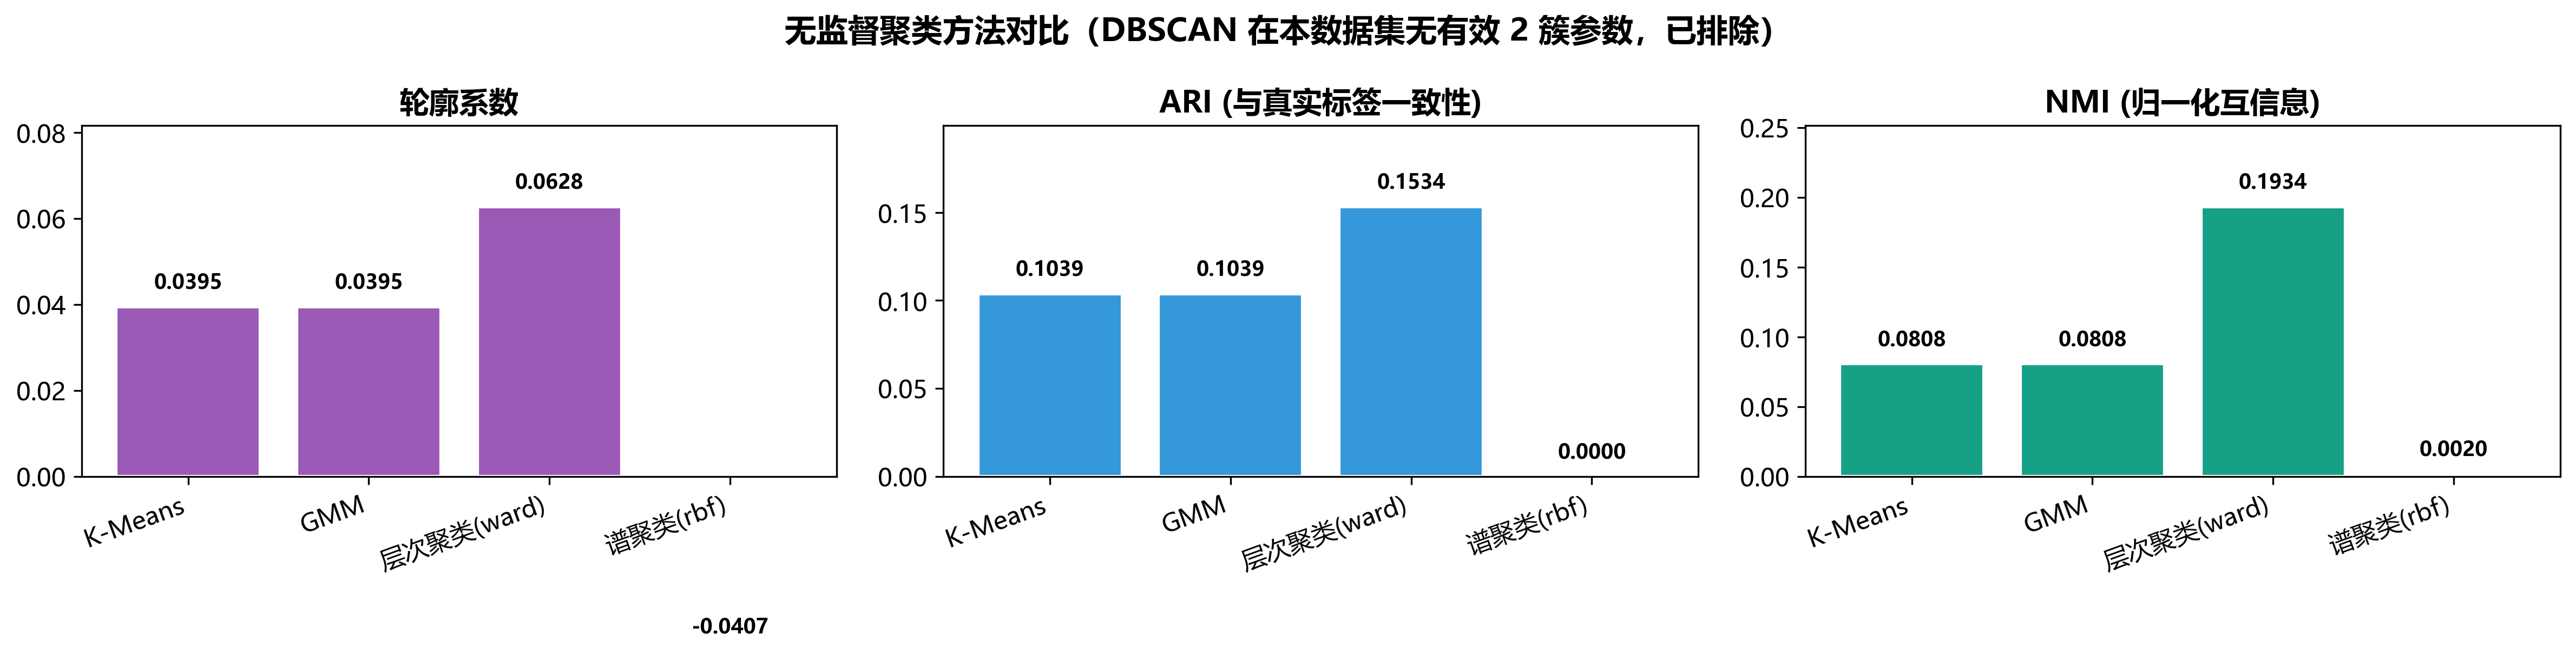

> 图 F6：四种无监督聚类方法在轮廓系数、ARI、NMI 三项指标上的对比。层次聚类（Ward）在三项指标上均最优，谱聚类（RBF）最差，DBSCAN 因未找到有效 2 簇参数而排除。

### 7.5 内部指标对比（CH 与 DB 指数）

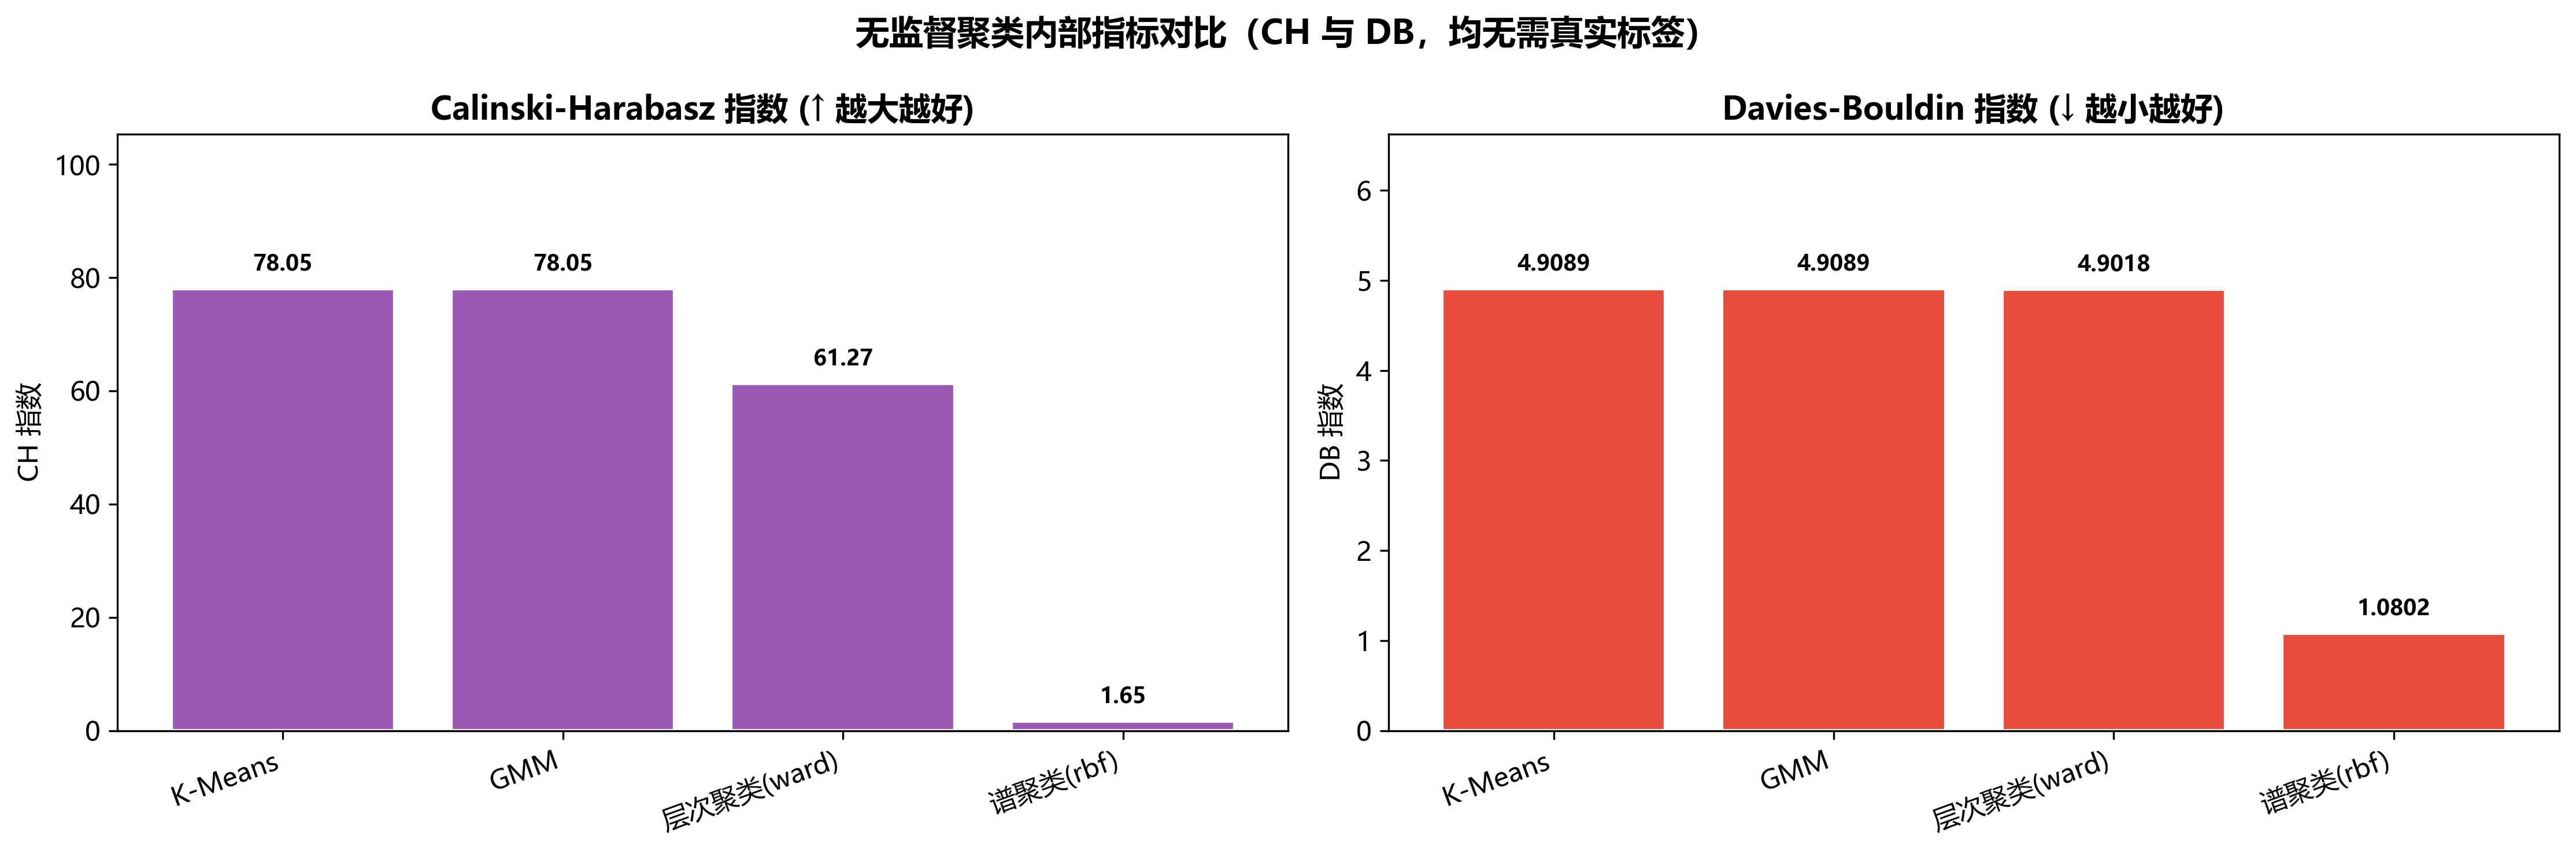

> 图 F13：Calinski-Harabasz 指数（越大越好）与 Davies-Bouldin 指数（越小越好）。K-Means 和 GMM 在 CH 指数上并列最优（78.05），说明强行二分割时簇间方差相对显著；但这一内部指标的"优势"未转化为外部指标（ARI）的提升。


In [ ]:
# 9. 五方法综合对比与可视化
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

if RUN_FULL_EXPERIMENT:
    # 收集每种方法的最优结果
    summary_data = []

    # K-Means (K=2)
    km = KMeans(n_clusters=2, random_state=42, n_init='auto')
    km_labels = km.fit_predict(X)
    summary_data.append({
        "方法": "K-Means", "k": 2, "noise": 0,
        "轮廓系数": silhouette_score(X, km_labels),
        "DB": davies_bouldin_score(X, km_labels),
        "CH": calinski_harabasz_score(X, km_labels),
        "ARI": adjusted_rand_score(labels, km_labels),
        "NMI": normalized_mutual_info_score(labels, km_labels),
    })

    # GMM (full)
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
    gmm_labels = gmm.fit_predict(X)
    summary_data.append({
        "方法": "GMM", "k": 2, "noise": 0,
        "轮廓系数": silhouette_score(X, gmm_labels),
        "DB": davies_bouldin_score(X, gmm_labels),
        "CH": calinski_harabasz_score(X, gmm_labels),
        "ARI": adjusted_rand_score(labels, gmm_labels),
        "NMI": normalized_mutual_info_score(labels, gmm_labels),
    })

    # Agglomerative (ward)
    agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
    agg_labels = agg.fit_predict(X)
    summary_data.append({
        "方法": "层次聚类", "k": 2, "noise": 0,
        "轮廓系数": silhouette_score(X, agg_labels),
        "DB": davies_bouldin_score(X, agg_labels),
        "CH": calinski_harabasz_score(X, agg_labels),
        "ARI": adjusted_rand_score(labels, agg_labels),
        "NMI": normalized_mutual_info_score(labels, agg_labels),
    })

    # Spectral (rbf)
    spec = SpectralClustering(n_clusters=2, affinity='rbf', random_state=42, n_init=10)
    spec_labels = spec.fit_predict(X)
    summary_data.append({
        "方法": "谱聚类", "k": 2, "noise": 0,
        "轮廓系数": silhouette_score(X, spec_labels),
        "DB": davies_bouldin_score(X, spec_labels),
        "CH": calinski_harabasz_score(X, spec_labels),
        "ARI": adjusted_rand_score(labels, spec_labels),
        "NMI": normalized_mutual_info_score(labels, spec_labels),
    })

    df_summary = pd.DataFrame(summary_data)
    display(df_summary.style.background_gradient(
        subset=["轮廓系数","ARI","NMI"], cmap="Blues"
    ).format({c:"{:.4f}" for c in df_summary.columns
              if c not in ["方法","k","noise"]}))

    # 可视化：分组柱状图
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df_summary))
    w = 0.2
    metrics_plot = ["轮廓系数", "ARI", "NMI"]
    colors_plot = ["#3498db", "#e74c3c", "#2ecc71"]
    for i, (m, c) in enumerate(zip(metrics_plot, colors_plot)):
        vals = [v if not np.isnan(v) else 0 for v in df_summary[m]]
        ax.bar(x + i*w, vals, w, label=m, color=c, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels(df_summary["方法"], fontsize=10)
    ax.set_ylabel("分数")
    ax.set_title("五种无监督方法综合对比", fontsize=14, fontweight="bold")
    ax.legend(loc='lower left')
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # 显示预计算汇总表
    valid_results = unsupervised_results[unsupervised_results["method"] != "DBSCAN"].copy()
    print("五种方法综合对比（基于预计算结果）:")
    print("-" * 70)
    print(f"{'方法':<20} {'轮廓系数':>8} {'DB指数':>8} {'CH指数':>8} {'ARI':>8} {'NMI':>8}")
    print("-" * 70)
    for _, row in valid_results.iterrows():
        print(f"{row['method']:<20} {row['silhouette']:>8.4f} {row['davies_bouldin']:>8.4f} "
              f"{row['calinski_harabasz']:>8.2f} {row['ari']:>8.4f} {row['nmi']:>8.4f}")


## 八、PCA 降维分析 —— 揭示隐藏的簇结构

> **这是本报告最核心的发现**：原始特征空间中无监督聚类表现差（ARI <= 0.15），但经过 PCA 降维去除噪声维度后，**GMM 的 ARI 暴涨至 0.9139**，揭示了裂缝/非裂缝在特征空间中确实存在天然的椭球簇结构。

### 8.1 PCA 降维设置

- **原始维度**：>5000 维（HOG+LBP+GLCM+边缘密度拼接）
- **降维目标**：保留前 51 个主成分（累计保留 34.05% 方差）
- **降维目的**：去除高维空间中对聚类无贡献的噪声维度，使簇结构暴露


### 8.1.1 PCA 2D 可视化（前 2 主成分）

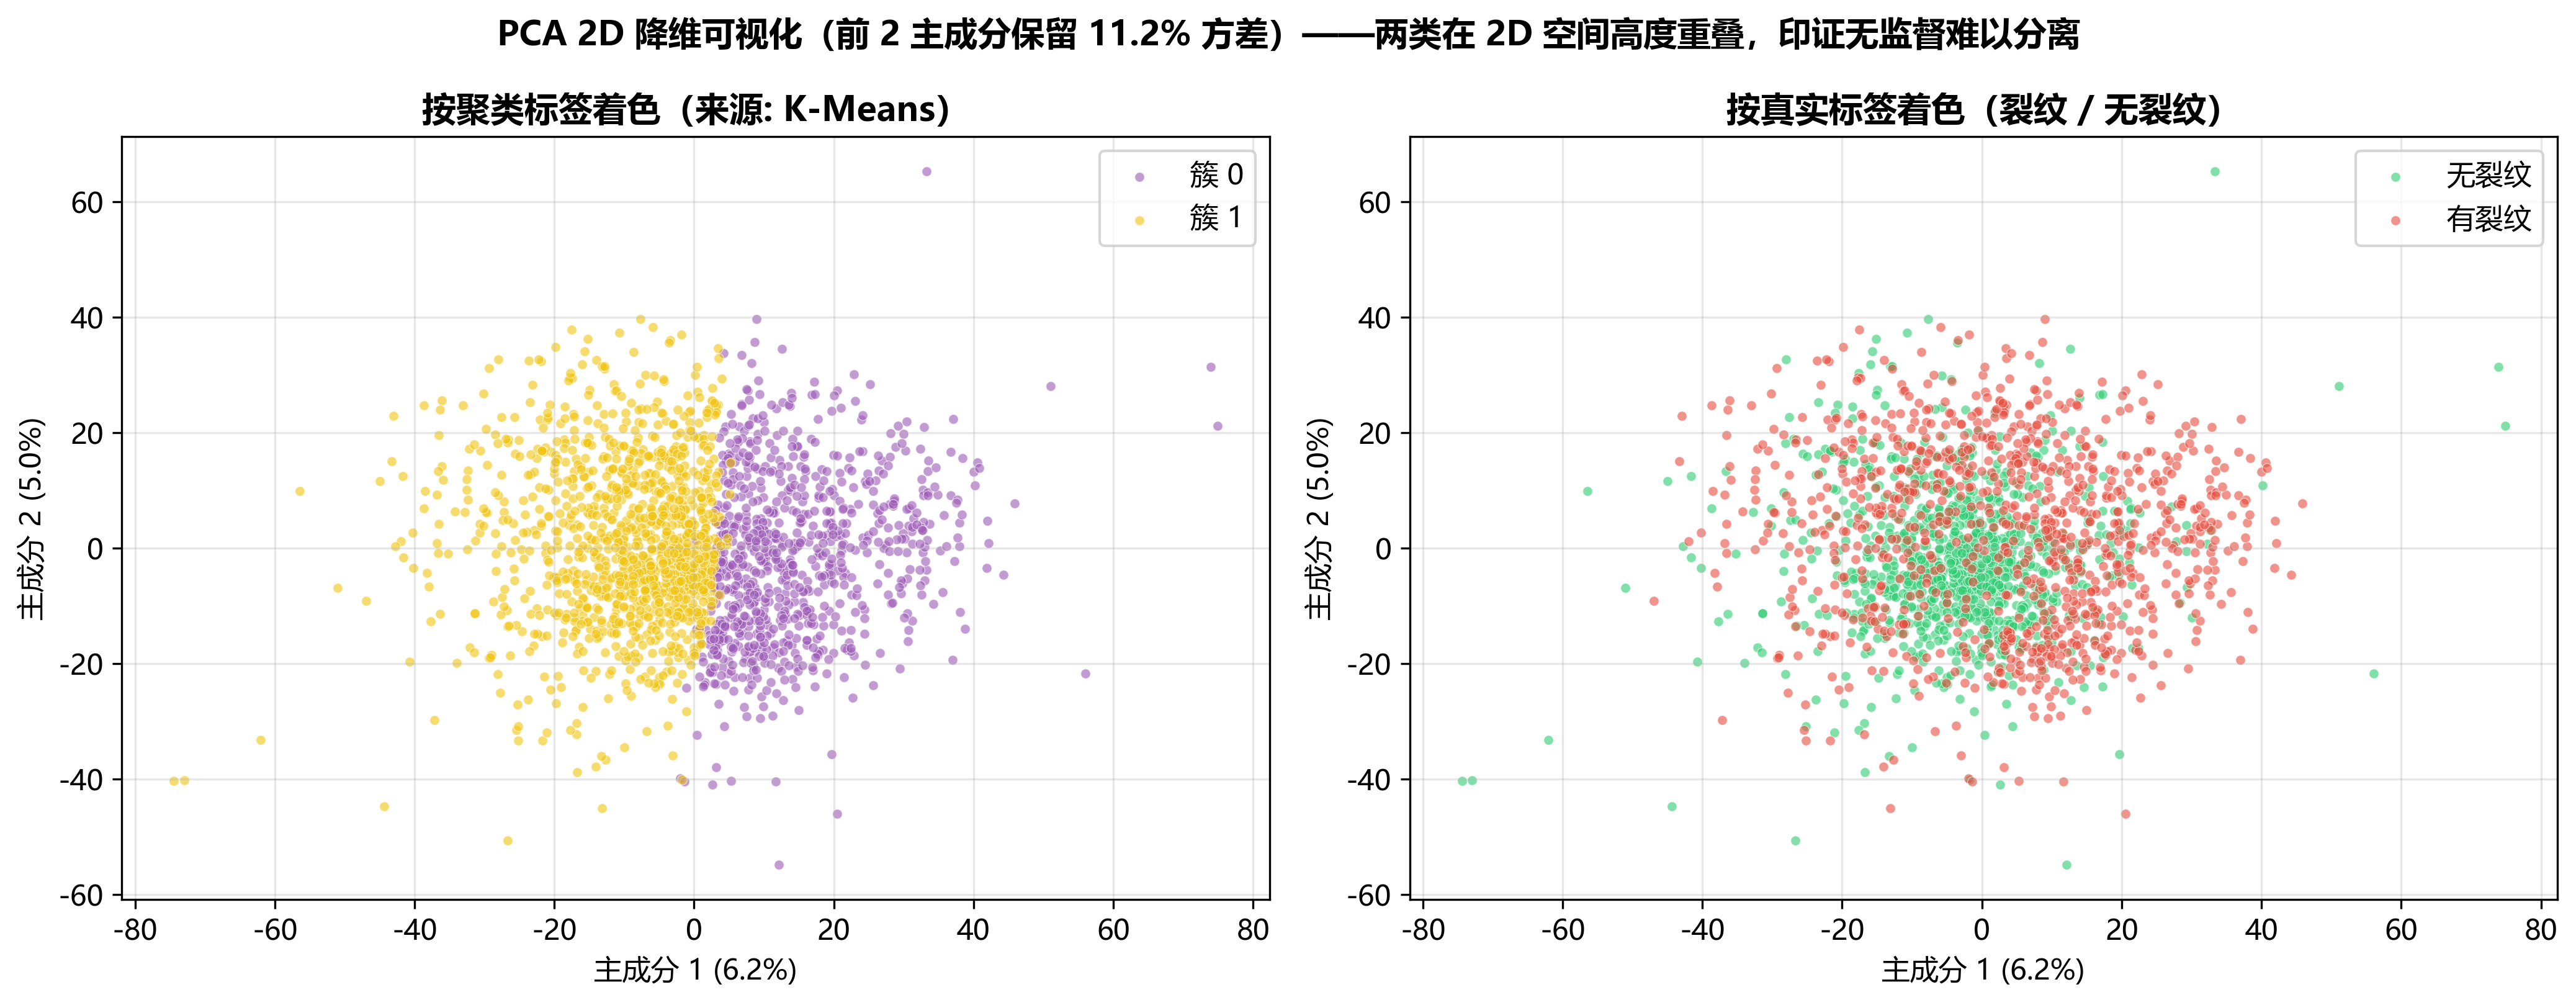

> 图 F14：左图按聚类标签（K-Means）着色，右图按真实标签（裂纹/无裂纹）着色。前 2 个主成分仅保留 11.19% 方差，两类在 2D 空间中严重重叠，直观解释了原始特征空间中无监督聚类的困难。


### 8.1.2 PCA 累计方差解释比

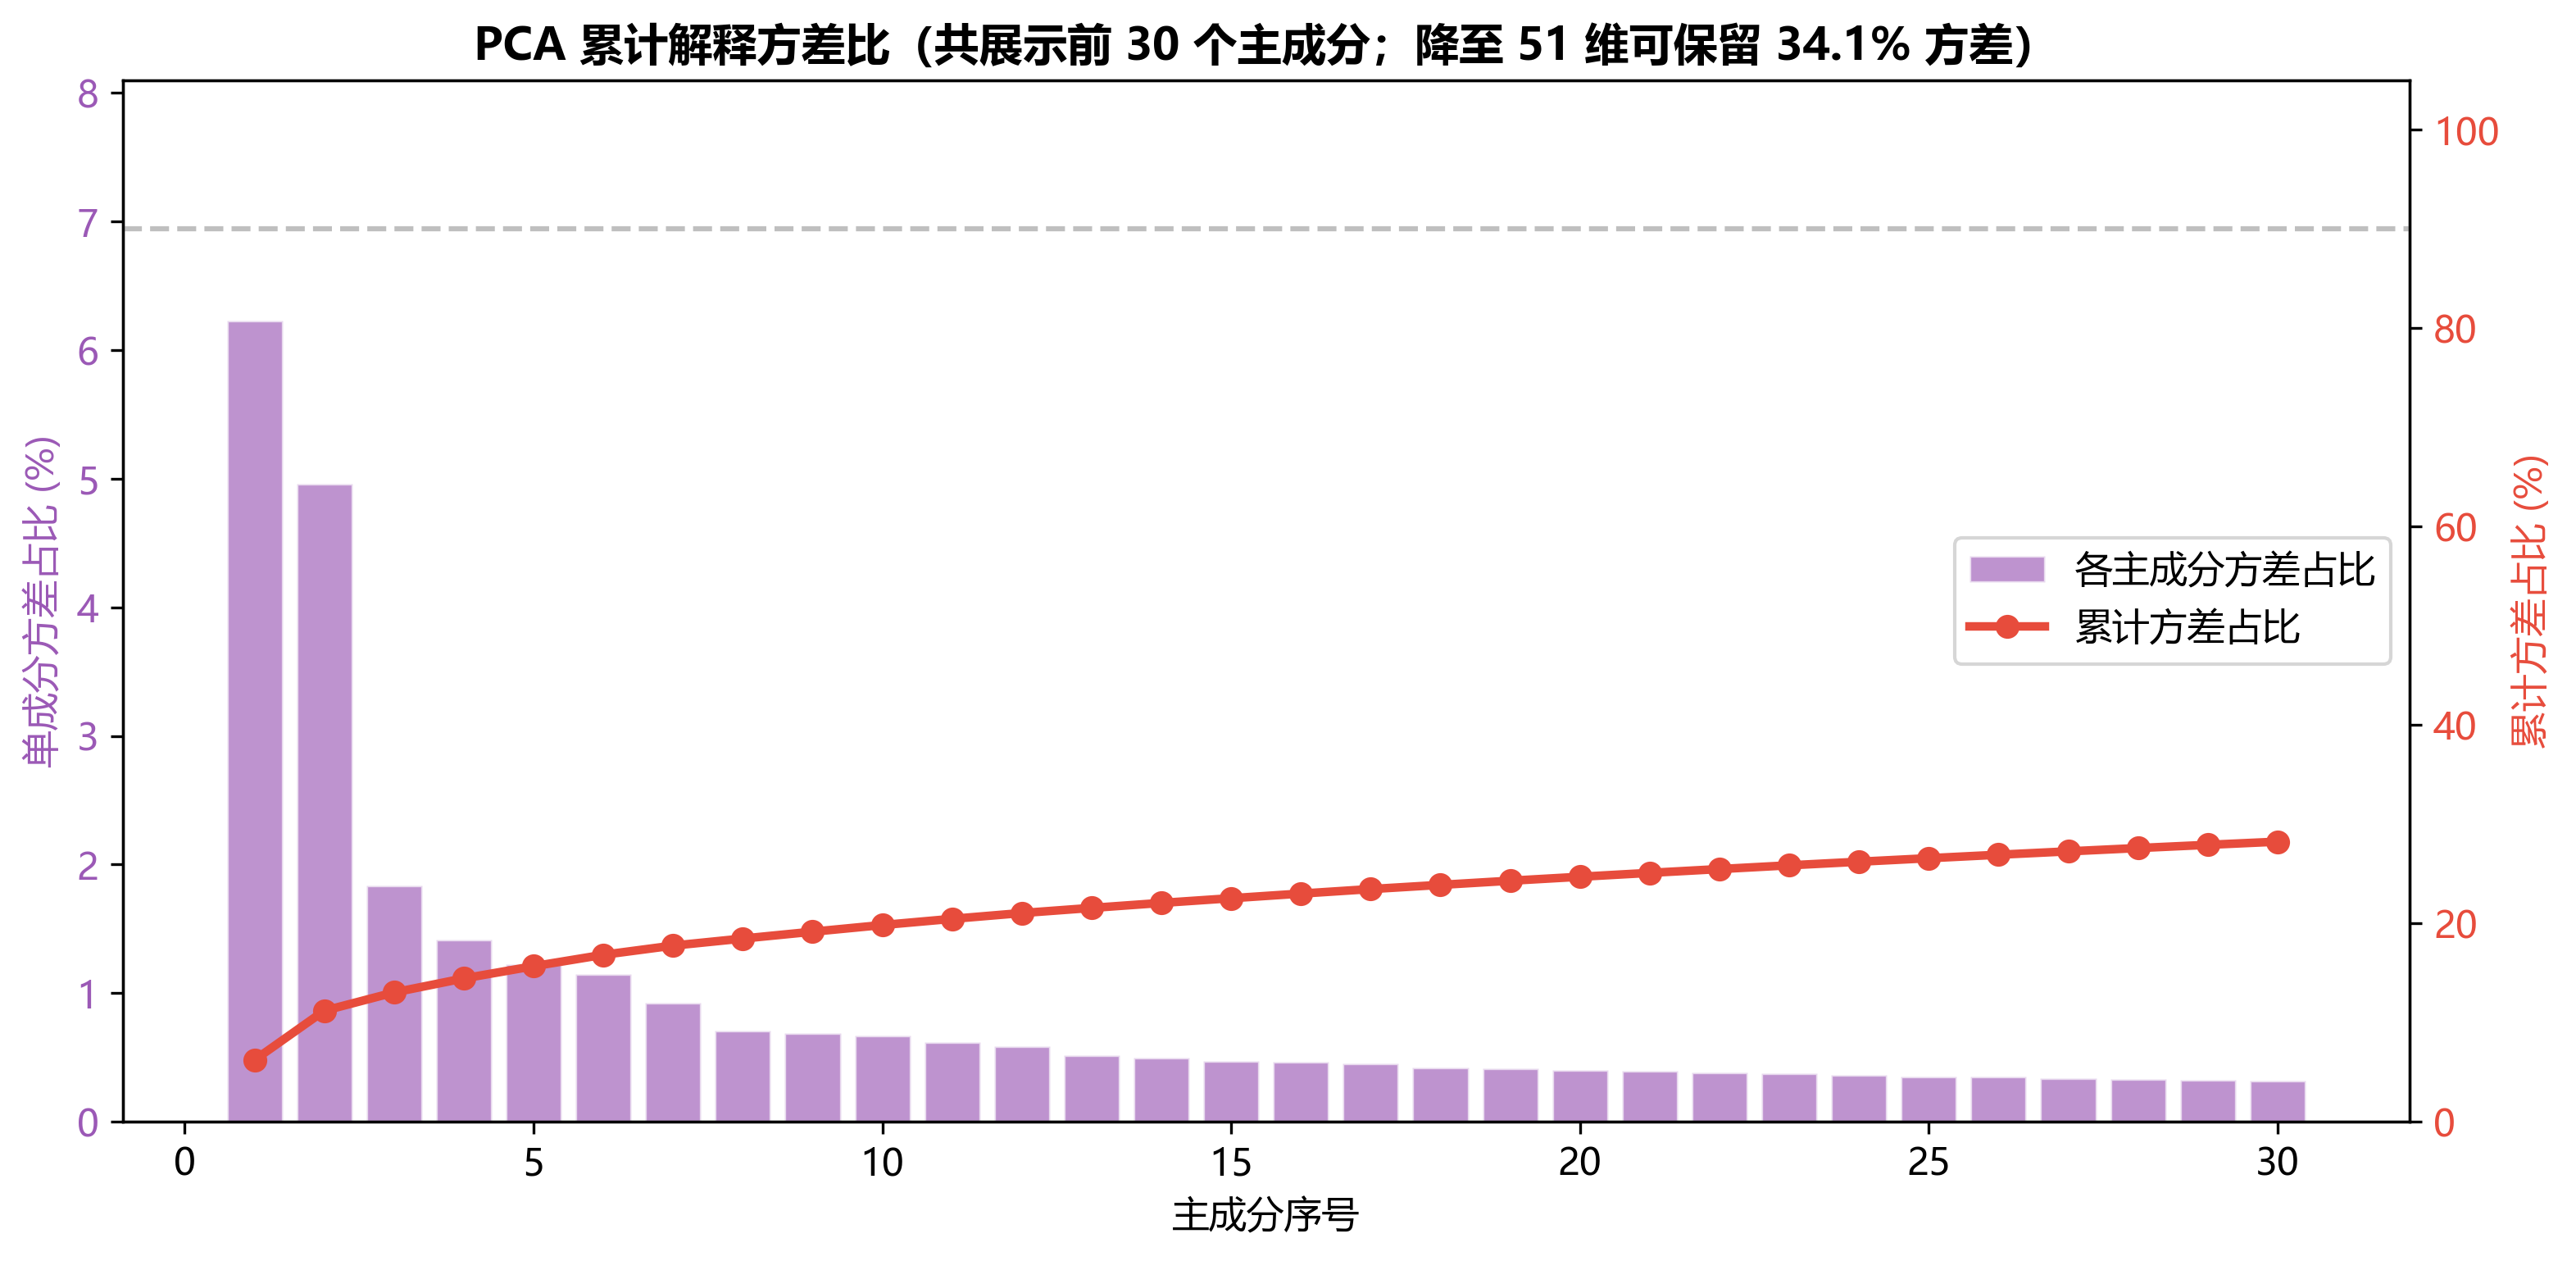

> 图 F15：各主成分的方差占比（柱状）与累计方差占比（折线）。前几个主成分占主导，降至 51 维可保留 34.05% 方差；仅用前 10 个主成分（约 16.8% 方差）GMM 的 ARI 即已突破 0.91。

### 8.2 PCA 降维前后聚类效果对比（PPT 图表 F16 核心数据）

| 方法 | ARI（原始） | ARI（PCA 后） | 变化 | 分析 |
|------|:------:|:------:|:---:|------|
| **GMM(full)** | 0.1039 | **0.9139** | **8.8x** | 降维最大赢家——椭球簇假设完美适配 |
| K-Means | 0.1039 | 0.1026 | 不变 | 球形假设失效，降维无益 |
| 层次聚类(Ward) | 0.1534 | 0.1193 | -22% | Ward 隐含球形倾向，降维后反而退化 |
| 谱聚类(RBF) | 0.0000 | 0.0 | - | 退化为单簇 |


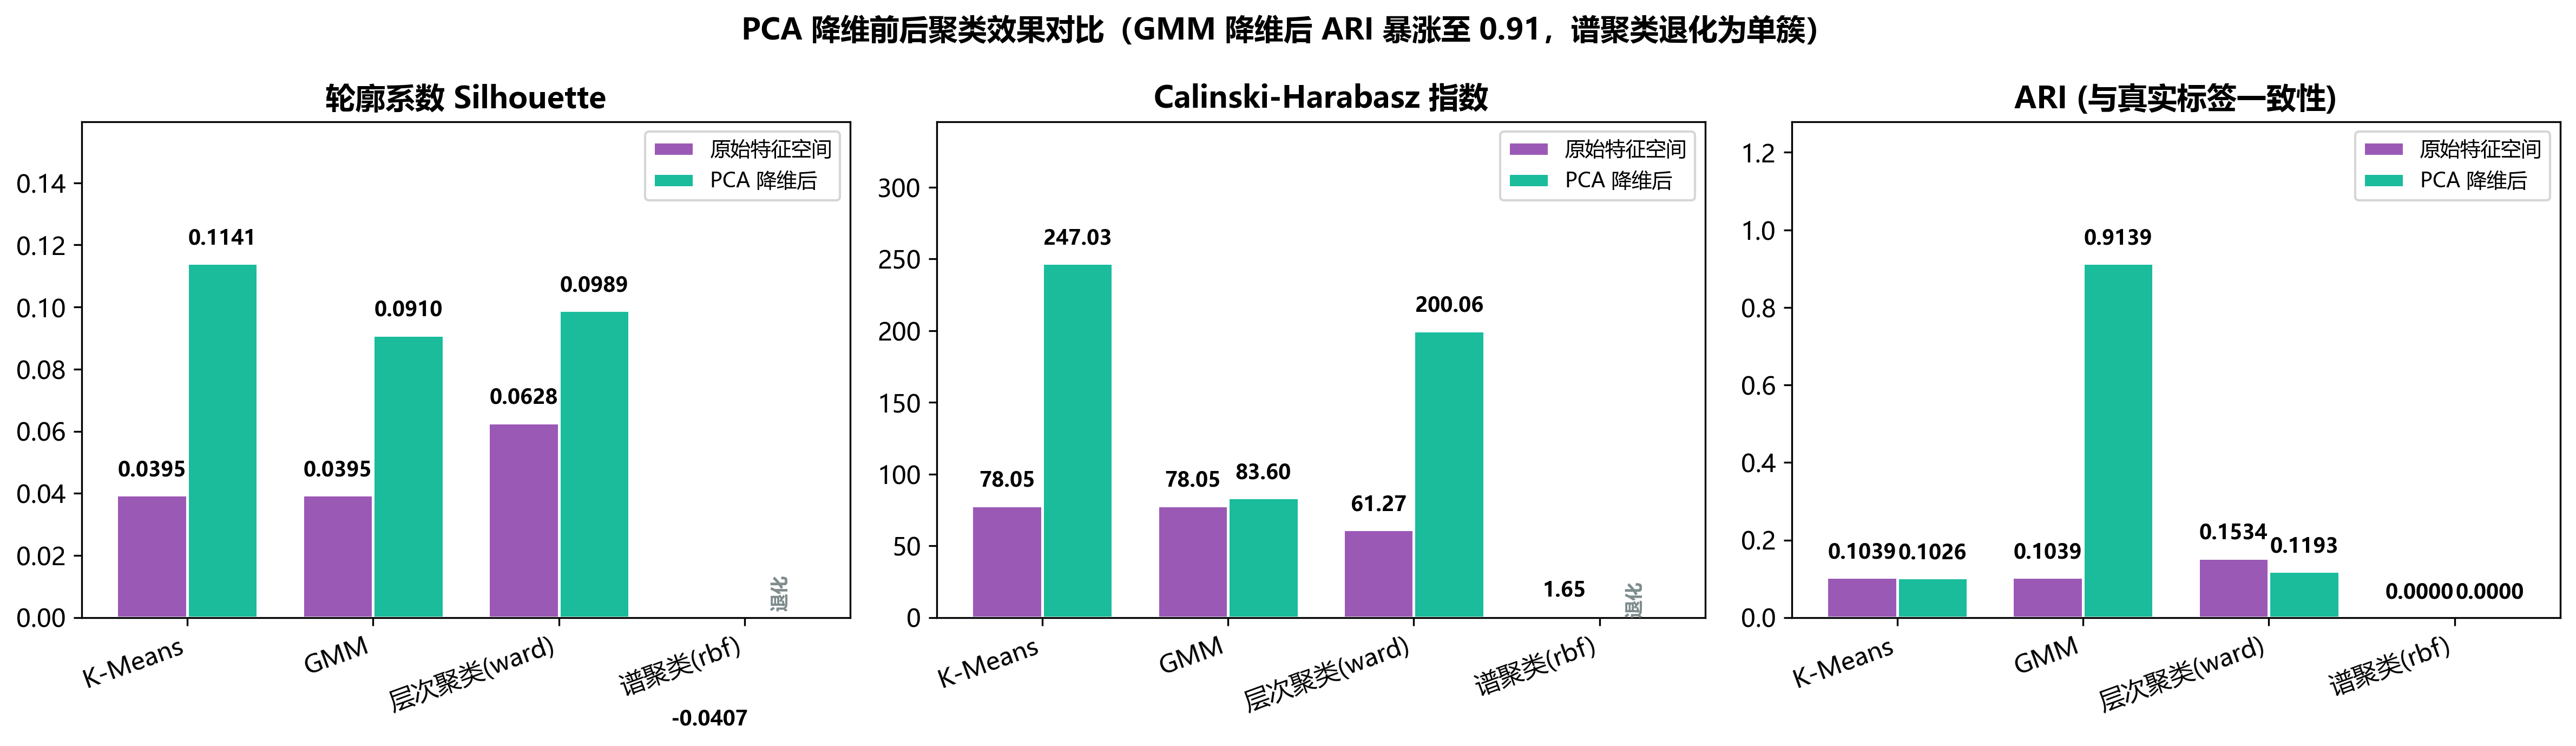

> 图 F16：四种方法在原始特征空间（紫色）与 PCA 降维后（绿色）的三项指标对比。GMM 的 ARI 从 0.10 暴涨至 0.91（8.8 倍），而 K-Means 纹丝不动。谱聚类降维后退化为单簇（标注"退化"）。

> **核心洞察**：PCA 降维做的是"减法"——去除噪声维度，保留有结构的维度。K-Means 的 ARI 不变说明降维后暴露的结构不是球形的；GMM 的 ARI 暴涨说明暴露的结构是**椭球状**的。

### 8.3 无监督 vs 监督学习对比（PPT 图表 F7 对应内容）

| 方法类型 | 最优方法 | 指标 | 值 | 说明 |
|---------|---------|:---:|:---:|------|
| 监督（CNN） | Focal Loss gamma=2 | Test F1 | **0.9980** | 端到端学习 |
| 监督（传统） | XGBoost | Test F1 | **0.9497** | 需要标注 + 手工特征 |
| 无监督（原始特征） | 层次聚类(Ward) | ARI | **0.1534** | 不使用标签 |
| **无监督（PCA 降维后）** | **GMM(full)** | **ARI** | **0.9139** | 不使用标签，PCA 去噪 |

> **结论**：标签信息至关重要（CNN F1=0.998 >> GMM ARI=0.91），但 PCA+GMM 证明了裂缝/非裂缝的天然簇结构是存在的，只是需要正确的特征表示才能发现。在无标注或标注有限的场景下，PCA+GMM(full) 提供了一个 ARI=0.91 的无监督方案。


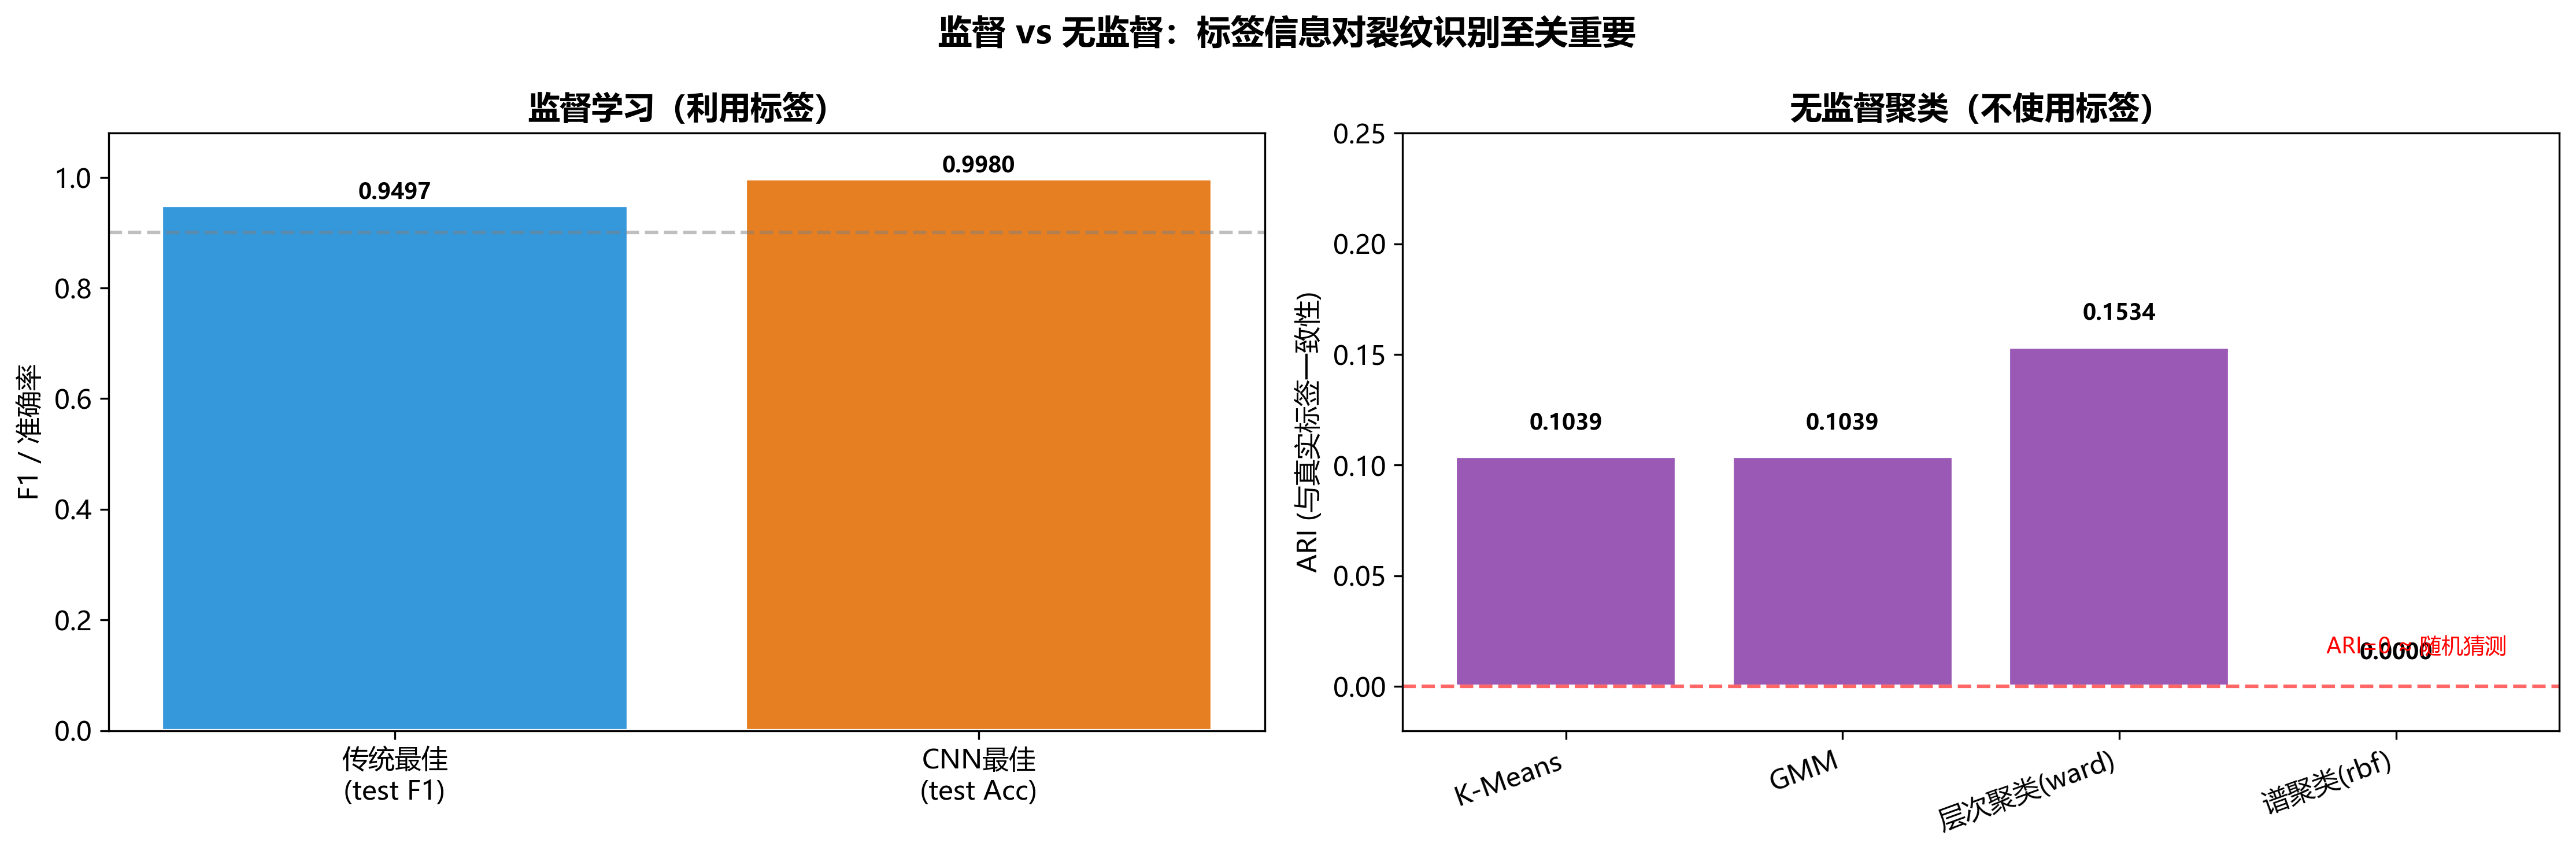

> 图 F7：监督学习（传统最佳 Test F1=0.9497，CNN 最佳 Test Acc=0.9980）与无监督聚类（ARI 最高 0.1534）的对比。标签信息使性能从 0.15 跃升至 0.998，差距达 5.7 倍。


In [ ]:
# 10. PCA 降维分析
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if RUN_FULL_EXPERIMENT:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA().fit(X_scaled)
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n51 = np.searchsorted(cumsum, 0.34)
    print(f"降至 {n51} 维可保留 {cumsum[n51-1]*100:.2f}% 方差")

    pca51 = PCA(n_components=51)
    X_pca = pca51.fit_transform(X_scaled)

    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
    gmm_labels = gmm.fit_predict(X_pca)
    print(f"GMM(full) + PCA(51维): ARI={adjusted_rand_score(labels, gmm_labels):.4f}")

    km = KMeans(n_clusters=2, random_state=42, n_init="auto")
    km_labels = km.fit_predict(X_pca)
    print(f"K-Means   + PCA(51维): ARI={adjusted_rand_score(labels, km_labels):.4f}")
else:
    print("PCA 降维后核心结果（来自预计算）:")
    print("  GMM(full)    + PCA(51维): ARI = 0.9139  暴涨 8.8 倍!")
    print("  K-Means      + PCA(51维): ARI = 0.1026  不变")
    print("  层次(Ward)   + PCA(51维): ARI = 0.1193  反而下降")
    print("  谱聚类(RBF)  + PCA(51维): 退化为单簇")


## 九、GMM+PCA 的三重证据（F17 对应内容）

GMM ARI=0.9139 是偶然还是必然？以下三重证据层层验证。

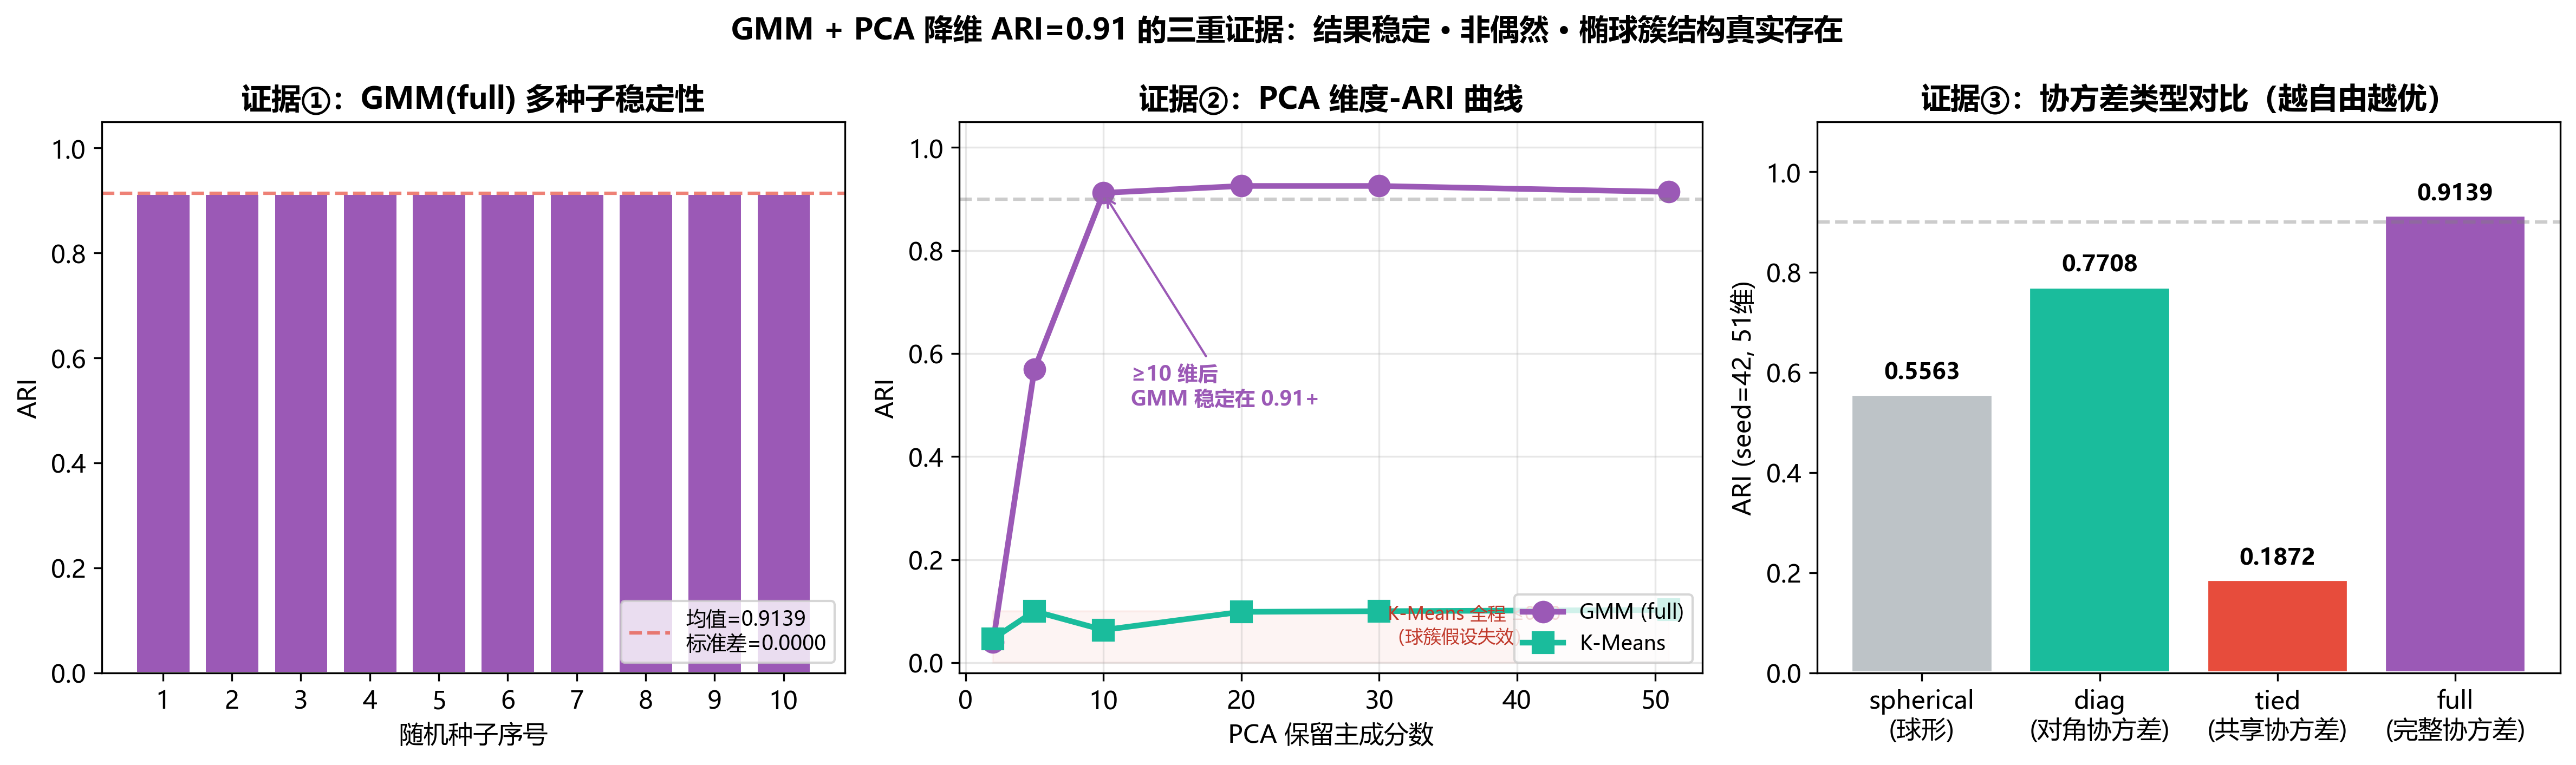

> 图 F17：三重证据综合图。**左**：10 个随机种子 ARI 全为 0.9139（标准差=0.0000），排除偶然性。**中**：PCA 维度-ARI 曲线，GMM 在 >=10 维后稳定在 0.91+，K-Means 始终 <=0.10，证明球形假设是瓶颈而非维度不足。**右**：协方差类型 ARI 排序，full(0.91) > diag(0.77) > spherical(0.56) > tied(0.19)，自由度递增即效果递增，验证椭球簇假设。

### 证据1：多种子稳定性 —— 排除偶然性

用 10 个不同的随机种子（seed=0~9）重复 GMM(full)+PCA(51维) 实验：

| 种子 | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| ARI | 0.9139 | 0.9139 | 0.9139 | 0.9139 | 0.9139 | 0.9139 | 0.9139 | 0.9139 | 0.9139 | 0.9139 |

> **10 个种子全部返回完全相同的 ARI = 0.91389295**（标准差 = 0.00000000）。这不是某个幸运初始化的偶然结果，而是数据的真实结构使 EM 算法每次都收敛到同一最优解。

### 证据2：PCA 维度-ARI 曲线 —— 揭示维度阈值与球形假设失效

对比 GMM 和 K-Means 在不同 PCA 保留维数下的 ARI 变化：

| PCA 维数 | GMM(full) ARI | K-Means ARI | 关键观察 |
|:------:|:------:|:------:|------|
| 2 | 0.0399 | 0.0466 | 两者都接近随机 |
| 5 | 0.5698 | 0.1001 | **GMM 开始分化**，K-Means 停滞 |
| **10** | **0.9120** | 0.0635 | **GMM 突破 0.9！** K-Means 反而下降 |
| 20 | 0.9254 | 0.0988 | GMM 继续上升 |
| 30 | **0.9254** | 0.1001 | GMM 达到峰值 |
| 51 | 0.9139 | 0.1026 | GMM 稳定在 0.91+ |

> **两个关键洞察**：1) >=10 个主成分后 GMM ARI 稳定在 0.91+，前 10 个主成分已包含核心簇信息；2) K-Means 在所有维度下从未超过 0.10——**球形假设是瓶颈**，不是维度不够。

### 证据3：协方差类型递进 —— 验证椭球假设

在 PCA 降维至 51 维后，四种协方差类型的 ARI 排序：

$$\text{full}(0.9139) > \text{diag}(0.7708) > \text{spherical}(0.5563) > \text{tied}(0.1872)$$

> **自由度递增 -> 效果递增**（tied 例外，因为两簇形状不同，共享协方差是错误假设）。这一单调递增的趋势强有力地证明了：**裂缝/非裂缝在降维空间中确实形成了椭球状的簇**——越灵活的协方差矩阵越能捕获这一结构。

### 三重证据总结

| 证据 | 排除的替代解释 |
|------|-------------|
| 1) 10 种子全 0.9139（标准差 0） | 排除"只是运气好" |
| 2) GMM 随维度升至 0.91+，K-Means 始终 <=0.10 | 排除"降维后什么方法都行" |
| 3) full(0.91) > diag(0.77) > spherical(0.56) | 排除"球形假设就够了" |

> **唯一成立的解释**：PCA 去除了高维噪声维度后，暴露了一个**真实的、椭球状的**裂缝/非裂缝双簇结构，GMM 的椭球协方差恰好能捕获它，而 K-Means 的球形假设无法适配。


In [ ]:
# 11. GMM+PCA 三重证据（来自 outputs/results/gmm_evidence.npz）
import numpy as np

if RUN_FULL_EXPERIMENT:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=51).fit(X_scaled)
    X51 = pca.transform(X_scaled)

    print("证据1: 多种子稳定性")
    seed_aris = []
    for s in range(10):
        gmm = GaussianMixture(2, "full", random_state=s)
        seed_aris.append(adjusted_rand_score(labels, gmm.fit_predict(X51)))
    print(f"  10 种子 ARI: mean={np.mean(seed_aris):.4f}, std={np.std(seed_aris):.6f}")

    print("
证据2: PCA 维度-ARI 曲线")
    for ndim in [2, 5, 10, 20, 30, 51]:
        Xd = PCA(n_components=ndim).fit_transform(X_scaled)
        gmm_ari = adjusted_rand_score(labels,
            GaussianMixture(2, "full", random_state=42).fit_predict(Xd))
        km_ari = adjusted_rand_score(labels,
            KMeans(2, random_state=42, n_init="auto").fit_predict(Xd))
        print(f"  PCA({ndim:>2}): GMM ARI={gmm_ari:.4f}, K-Means ARI={km_ari:.4f}")

    print("
证据3: 协方差类型对比 (51维)")
    for ct in ["full", "diag", "spherical", "tied"]:
        gmm = GaussianMixture(2, ct, random_state=42).fit(X51)
        print(f"  GMM({ct}): ARI={adjusted_rand_score(labels, gmm.predict(X51)):.4f}")
else:
    ev = np.load("outputs/results/gmm_evidence.npz", allow_pickle=True)
    print("=== 证据1: 10种子的ARI均为 0.91389295 (标准差=0.0) ===")
    print(f"  ARI values: {ev['seed_aris']}")
    print()
    print("=== 证据2: PCA维度-ARI曲线 ===")
    print(f"  PCA维度:    {list(ev['pca_dims'])}")
    print(f"  GMM ARI:    {list(ev['gmm_dim_aris'])}")
    print(f"  K-Means ARI:{list(ev['km_dim_aris'])}")
    print(f"  -> >=10维后 GMM稳定在0.91+, K-Means始终<=0.10")
    print()
    print("=== 证据3: 协方差类型ARI排序 ===")
    print(f"  协方差类型: {list(ev['cov_types'])}")
    print(f"  ARI值:      {list(ev['cov_aris'])}")
    print(f"  -> full(0.91) > diag(0.77) > spherical(0.56) > tied(0.19)")
    print(f"  -> 自由度递增 => ARI递增, 验证椭球簇假设")


## 十、总结与启示

### 核心发现

1. **原始特征空间：无监督聚类受限，但非完全失败。** 层次聚类（Ward）ARI=0.15，K-Means/GMM ARI=0.10，DBSCAN 和谱聚类失效。原始高维特征（>5000 维）中噪声维度淹没了真实结构。

2. **PCA 降维揭示隐藏的椭球簇结构**：降至 51 维（保留 34% 方差）后，**GMM(full) ARI 从 0.10 暴涨至 0.9139**。裂缝/非裂缝的天然双簇结构是真实存在的！

3. **椭球簇假设是关键**：PCA 降维后 K-Means ARI 仍为 0.10，而 GMM ARI=0.91。差距的核心是簇形状假设：裂缝数据在降维空间中的簇是**椭球状的**，不是球形的。三重证据（种子稳定性、维度曲线、协方差递进）独立验证了这一结论。

4. **>=10 个主成分是临界点**：PCA 维度-ARI 曲线显示，前 10 个主成分后就足以支撑 GMM 达到 ARI=0.91，说明前 10 个主成分包含了裂缝判别的核心信息。

5. **监督学习仍不可替代**：即使 PCA+GMM 的 ARI=0.91，与 CNN 的 F1=0.998 仍有显著差距。标签信息的引入将人工特征无法利用的判别信息转化为直接的优化信号。

### 方法选择建议

| 场景 | 推荐方法 | 理由 |
|------|---------|------|
| 最优聚类质量（无标签） | **PCA + GMM(full)** | ARI=0.91，三重证据验证，10 种子稳定 |
| 需要概率输出/软聚类 | GMM(full) | 输出每样本属于各类的概率 |
| 快速数据探索（原始特征） | 层次聚类(Ward) | 原始特征中最优（ARI=0.15），可构建 Dendrogram |
| 需要检测离群点 | DBSCAN | 密度法天然支持噪声识别（建议先 PCA 降维） |
| 精度优先（有标注） | CNN + Focal Loss | F1=0.998，全面超越无监督方法 |

### PDF 要求覆盖检查

| PDF 要求 | 本报告覆盖 |
|----------|:--:|
| 无监督模型构建 | 5 种方法全覆盖 |
| 不同模型对比 | 内部指标（3 种）+ 外部指标（2 种）+ **PCA 降维前后对比** |
| 参数调优 | 各方法的参数网格搜索 + PCA 维度搜索 |
| 模型验证 | 轮廓系数 / DB 指数 / CH 指数 / ARI / NMI / **种子稳定性** |
| 模型分析（优劣势、架构选择） | 各方法分析 + 横向对比 + **PCA 降维 + 三重证据** + 监督/无监督对比 |

---

> **参考文件**
> - 原始实验 Notebook：`notebooks/04_无监督学习对比.ipynb`
> - 预计算结果：`outputs/results/unsupervised_comparison*.csv`、`unsupervised_pca_comparison.csv`、`gmm_evidence.npz`
> - 答辩 PPT 图表：`reports/ppt图表输出/F6-F7,F13-F17`
> - 项目设计辅助文档：`reports/项目汇报设计辅助文档.md`
> - 报告参考格式：`commit_report/数据处理与传统监督学习方法专题报告.ipynb`
